# Stress Response Study: the GB battery fleet under system tightness

**Research premise.** Batteries are dispatched for commercial return, but commercial price
signals and physical system stress are not the same thing. This notebook asks what the real
GB battery fleet actually *did* during the tightest periods on the system, using the
operator's own scarcity measures rather than a price-derived proxy.

**Population.** Every BM-registered GB battery site — the **90-site, 127-BM-Unit census**
reconstructed in notebook 06 — not the 23-site curated cross-section the live dashboard
renders. That distinction is the difference between a claim about the GB fleet and a claim
about a sample of it: the curated 23 are 45.5% of BM-registered battery MW and skew large and
transmission-connected, so a stress-response result computed on them alone would describe the
big end of the market and be quietly generalised to all of it.

**Four questions.**

1. **Physical availability** — is the fleet present when the system needs it? Net discharge,
   declared availability and (inferred) state of charge during the top-1% loss-of-load
   probability periods, the bottom-1% de-rated margin periods, and the periods Capacity
   Market Notices warned about.
2. **Stress modification** — does the fleet mitigate or amplify tightness? Net fleet demand
   (charge − discharge) by de-rated-margin band, and how often the fleet is *charging* while
   the margin is critically thin.
3. **Dynamic foresight** — does the fleet respond before or after stress materialises?
   How early tightness was visible in the forecast prints, and how state of charge and
   dispatch evolve into a critical period versus matched control periods.
4. **Consumer value** — does battery discharge suppress price spikes? Cashout spike
   frequency by fleet-discharge quartile, holding system stress constant.

**Data.** 2023-10-01 → present, GB, all public and free: Elexon FUELHH / ITSDO / LoLP-DRM /
per-BMU PN, MELS, MILS / B1770 cashout, Sheffield Solar PV_Live, and the NESO Capacity
Market Notice register. No API keys, no prices from subscription feeds — which is why this
window can be three winters long rather than the 60 days of
[`04_alignment_gap.ipynb`](04_alignment_gap.ipynb).

**Relationship to notebook 04.** 04 prices the *alignment gap* of a profit-optimal benchmark
against a relative (top-decile residual load) stress signal, over the ~60 days for which
free day-ahead prices exist. This notebook drops the benchmark and the prices, and instead
measures the **real fleet** against **operator-grade scarcity signals** over three winters.
The two are complements: 04 says what alignment costs, 05 says what the fleet actually did.

**Stated up front.** Physical Notifications are served final-only — Elexon does not publish
revision history — so Section 6 measures *realised dispatch* differences around a scarcity
signal, not proven reaction to it. Fleet state of charge is **inferred** from PNs, never
observed. Both are treated as first-class limitations, not footnotes.

In [1]:
%matplotlib inline

import datetime as dt
import importlib.util
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from fleet import performance as fleet_perf
from fleet.population import census_population
from live import resilience
from live.assets import bess_config

# The store builder is a script, not a package module — load it by path so the
# notebook and a background backfill run share exactly one implementation.
_spec = importlib.util.spec_from_file_location(
    "build_stress_store", REPO_ROOT / "scripts" / "build_stress_store.py"
)
bss = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(bss)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Consistent hexes with the dashboard's design system (same dict as notebook 04).
C = {
    "ink":       "#0b0b0b",
    "da":        "#2a78d6",
    "discharge": "#1baf7a",
    "charge":    "#eb6834",
    "cost":      "#e34948",
    "mid":       "#c98500",
    "soc":       "#4a3aa7",
    "ghost":     "#c3c2b7",
    "stress":    (0.89, 0.29, 0.28, 0.14),
    "surplus":   (0.11, 0.69, 0.48, 0.12),
}

# --- Window and knobs ------------------------------------------------------
# DRY_RUN builds a two-week store so the whole notebook runs in minutes; the
# full window is three winters and takes hours to fetch on a cold cache.
DRY_RUN = False

# The window is PINNED, not relative to today. A rolling `today() - 1` end date
# silently invalidates the store at every midnight, which re-fetches the days
# whose feeds publish late and quietly moves every number in the notebook —
# results must not depend on when the notebook happened to be run. Extend the
# study by editing this date and rebuilding deliberately.
FULL_START = dt.date(2023, 10, 1)
FULL_END = dt.date(2026, 8, 16)
WINDOW_END = FULL_END
WINDOW_START = (WINDOW_END - dt.timedelta(days=13)) if DRY_RUN else FULL_START
# The population studied. The live dashboard renders a curated 23-site
# cross-section because it must fetch and render in seconds; this notebook takes
# the full BM-registered census (notebook 06), because a claim about "the GB
# fleet under stress" computed on a sample is a claim about the sample.
#
# Each population writes its own store — a store holds site rows for exactly the
# fleet it was built from, so sharing one directory would silently change what
# the curated results mean.
POP = census_population()
STORE = bss.store_for(POP)
if DRY_RUN:
    STORE = STORE / "dry_run"

# --- Analysis constants ----------------------------------------------------
DRM_BANDS = [0, 1000, 2000, 4000, 7000, np.inf]
DRM_BAND_LABELS = ["<1,000", "1–2k", "2–4k", "4–7k", ">7k"]
SPIKE_LEVELS = (500.0, 1000.0)
DRM_CRITICAL_MW = 1000.0     # RQ2/RQ3 "critically thin margin"
HH = 0.5                     # hours per settlement period
LOOKBACK_HH = 24             # 12 h of half-hours for SoC run-up (RQ3b)
EVENT_HH = 12                # ±6 h around a trigger for the event study (RQ3c)
MAX_CONTROLS = 5             # matched controls per event
MIN_N_DIST = 10              # below this a set is a case study, not a distribution
SOC_CLAMP_MAX = 0.5          # SoC usability: at most half the time pinned at a bound
CYCLES_MIN = fleet_perf.ANCILLARY_CYCLES_THRESHOLD  # 0.3 cycles/day

CFG = bess_config()
ETA_C = CFG["charge_efficiency"]
ETA_D = CFG["discharge_efficiency"]

SITE_MW = {s.site: s.power_mw for s in POP.sites}
SITE_MWH = {s.site: s.capacity_mwh for s in POP.sites}

# Energy capacity is published only through Capacity Market agreements, and those
# match a BM Unit for a minority of census sites. Power is known for every site,
# so MW-normalised metrics span the whole fleet; anything divided by MWh — cycles
# and inferred state of charge above all — is restricted to this subset and says
# so wherever it appears. Guessing a duration would put a fabricated denominator
# under a headline number.
SITES_WITH_MWH = {s for s, mwh in SITE_MWH.items() if mwh == mwh}


def skip(reason):
    '''Uniform "nothing to work with" notice.'''
    print(f"n=0 — skipped: {reason}")


DAYS = bss.window_days(WINDOW_START, WINDOW_END)
print(f"Window     : {WINDOW_START} → {WINDOW_END}  ({len(DAYS)} days)"
      f"{'  [DRY RUN]' if DRY_RUN else ''}")
print(f"Store      : {STORE}")
print(f"Efficiency : ηc={ETA_C:.2f} ηd={ETA_D:.2f}")
print(f"Population : {POP.name} — {len(POP)} sites, {len(POP.bmu_ids())} BM Units, "
      f"{sum(SITE_MW.values()):,.0f} MW declared")
print(f"Energy cap : known for {len(SITES_WITH_MWH)} of {len(SITE_MW)} sites "
      f"({100 * len(SITES_WITH_MWH) / len(SITE_MW):.0f}%) — MWh-normalised metrics "
      f"use this subset only")

Window     : 2023-10-01 → 2026-08-16  (1051 days)
Store      : /Users/abhinav/Documents/code/power-trading/data/processed/stress_study_census
Efficiency : ηc=0.94 ηd=0.94
Population : census — 90 sites, 127 BM Units, 6,348 MW declared
Energy cap : known for 42 of 90 sites (47%) — MWh-normalised metrics use this subset only


## Methodology definitions

Everything the poster needs to state, fixed before any number is computed.

| Term | Definition |
|---|---|
| **Window** | 2023-10-01 → yesterday, UTC settlement days, half-hourly grid |
| **Residual load** | ITSDO transmission demand − FUELHH wind − PV_Live embedded solar; a missing component propagates as NaN and the period is excluded, never zero-filled |
| **Sign convention** | Physical Notification positive = export (discharge). Fleet net MW = Σ site PN MW; negative fleet net MW = the fleet is a *load* |
| **Online site** | A settlement day between that site's first and last observed PN day |
| **Normalised fleet response** | fleet net MW ÷ online nameplate MW — the fleet roughly doubled over the window, so absolute MW is not comparable across it |
| **Core panel** | Sites online within 30 days of the window start and still active at the end; used where a fixed composition matters |
| **Availability factor** | Σ site MELS (declared export limit) ÷ Σ online nameplate MW |
| **C_LOLP** | Loss-of-load probability ≥ its 99th percentile over periods with a print; if that percentile is zero (LoLP is 0 almost everywhere) the set falls back to LoLP > 0, and the notebook says so |
| **C_DRM** | De-rated margin ≤ its 1st percentile |
| **C_DRM1000** | De-rated margin < 1,000 MW |
| **C_CMN** | Period overlaps an issued Capacity Market Notice window (half-open intervals; an open notice covers its target period) |
| **Cannibalistic charging** | Share of a set's periods with fleet net MW < 0 |
| **SoC inference (primary)** | Per site, `SoC(t+1) = clip(SoC(t) + (charge·ηc − discharge/ηd)·0.5h, 0, capacity)`, starting at 50%, η from the benchmark config. Clamps at the bounds act as re-anchors |
| **SoC usability** | A site's inferred SoC enters fleet aggregates only if it cycles ≥ 0.3×/day (below that the site is ancillary-parked and PNs miss its throughput) and is clamped ≤ 50% of the time |
| **SoC sensitivity** | Re-anchor to 50% daily at 04:00 UTC; headline SoC numbers are reported under both schemes and disagreement is reported, not resolved silently |
| **Matched controls** | Same half-hour of day, same calendar month (any year in window), on a day containing no critical period; ≤ 5 per event |
| **Trigger (RQ3c)** | Publish time of the first forecast print for a period with DRM < 1,000 MW or LoLP > 0 |
| **Spike** | Cashout price > £500/MWh and > £1,000/MWh (GB has a single cashout price post-2015, so SBP alone suffices) |
| **Volatility Dampening Index** | Within DRM-decile bins: (P95 − P50 of cashout \| bottom discharge tercile) − (P95 − P50 \| top tercile), averaged weighted by period count. Positive ⇒ price tails are compressed when the fleet discharges, at equal system stress |

## 1. Data acquisition and coverage

Eight feeds, day-cached, assembled once into tidy parquet tables by
`scripts/build_stress_store.py`. Everything downstream reads those tables, so the analysis
re-runs in seconds. Days that fail are recorded and skipped rather than sinking the build —
the coverage table below is the honest statement of what the study is actually computed on.

In [2]:
if not bss.store_is_current(STORE, DAYS):
    print("Store missing or stale — building (this is the slow, network-bound step).")
    bss.build_store(DAYS, STORE, population=POP)

S = bss.load_store(STORE)
system    = S["system"]
prints    = S["lolpdrm_prints"]
pn        = S["fleet_pn"]
mels      = S["fleet_mels"]
mils      = S["fleet_mils"]
sbp       = S["sbp"]
cmn       = S["cmn"]
coverage  = S["coverage"]

for name, frame in S.items():
    print(f"{name:16s} {len(frame):>9,} rows")

system              50,447 rows
lolpdrm_prints     251,391 rows
fleet_pn         3,163,404 rows
fleet_mels       3,163,411 rows
fleet_mils       3,163,408 rows
sbp                 50,448 rows
cmn                      6 rows
coverage             1,051 rows


         days_present  days_missing   first_day    last_day coverage
system           1051             0  2023-10-01  2026-08-16   100.0%
lolpdrm          1051             0  2023-10-01  2026-08-16   100.0%
pn               1051             0  2023-10-01  2026-08-16   100.0%
mels             1051             0  2023-10-01  2026-08-16   100.0%
mils             1051             0  2023-10-01  2026-08-16   100.0%
sbp              1051             0  2023-10-01  2026-08-16   100.0%


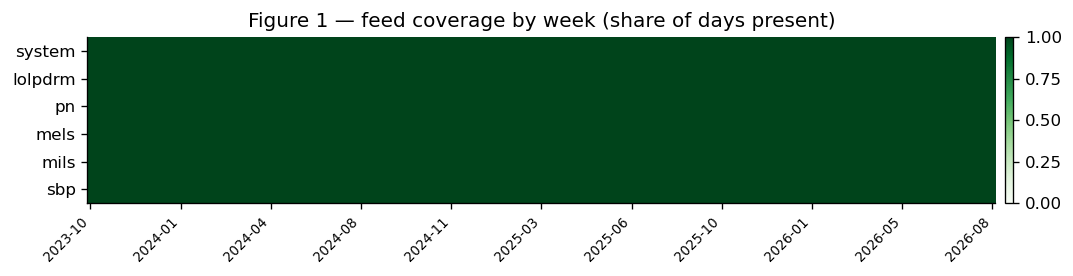


Every feed covers every day in the window.


In [3]:
FEEDS = [c for c in ("system", "lolpdrm", "pn", "mels", "mils", "sbp") if c in coverage]
cov = coverage.copy()
cov["date"] = pd.to_datetime(cov["date"])

summary = pd.DataFrame({
    "days_present": [int(cov[f].sum()) for f in FEEDS],
    "days_missing": [int((~cov[f]).sum()) for f in FEEDS],
    "first_day": [cov.loc[cov[f], "date"].min().date() if cov[f].any() else None for f in FEEDS],
    "last_day":  [cov.loc[cov[f], "date"].max().date() if cov[f].any() else None for f in FEEDS],
}, index=FEEDS)
summary["coverage"] = (summary["days_present"] / len(cov)).map(lambda v: f"{v:.1%}")
print(summary.to_string())

# Figure 1 — coverage by feed and week. Gaps that matter show up as vertical bands.
weekly = cov.set_index("date")[FEEDS].resample("W").mean()
fig, ax = plt.subplots(figsize=(9, 2.4))
im = ax.imshow(weekly.T.values, aspect="auto", cmap="Greens", vmin=0, vmax=1,
               extent=[0, len(weekly), len(FEEDS), 0], interpolation="nearest")
ax.set_yticks(np.arange(len(FEEDS)) + 0.5)
ax.set_yticklabels(FEEDS)
step = max(1, len(weekly) // 10)
ax.set_xticks(np.arange(0, len(weekly), step) + 0.5)
ax.set_xticklabels([d.strftime("%Y-%m") for d in weekly.index[::step]], rotation=45,
                   ha="right", fontsize=8)
ax.set_title("Figure 1 — feed coverage by week (share of days present)")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.tight_layout()
plt.show()

if summary["days_missing"].sum() == 0:
    print("\nEvery feed covers every day in the window.")
else:
    worst = summary["days_missing"].idxmax()
    print(f"\nSparsest feed: {worst} — {summary.loc[worst, 'days_missing']} missing day(s). "
          "Analyses below filter to periods where the feed they need is present.")

## 2. Fleet buildout and normalisation

The GB grid-scale battery fleet roughly doubled over this window, and the census is a
July-2026 snapshot — several tracked sites (Coalburn, Kilmarnock South) simply did not exist
in 2023. Comparing absolute fleet MW across the window would therefore measure commissioning,
not behaviour. Every later fleet statistic is normalised by **online nameplate MW**, and a
fixed **core panel** is available where composition must be held constant.

                                 first_pn     last_pn  power_mw  capacity_mwh   core
site                                                                                
Coalburn 1                     2025-10-31  2026-08-16   512.377      1000.000  False
Monk Fryston BESS BMU-1        2026-05-08  2026-08-16   320.000           NaN  False
Kilmarnock South               2025-07-31  2026-08-16   312.566       600.000  False
T_THURB-1                      2024-11-28  2026-08-16   300.000           NaN  False
Uskmouth                       2025-09-23  2026-08-16   230.000       460.000  False
Blackhillock                   2024-05-01  2026-08-16   208.840       400.000  False
Thornton                       2024-12-16  2026-08-16   200.000       400.000  False
Ferrybridge                    2024-11-29  2026-08-16   152.000       300.000  False
Wilton                         2024-06-01  2026-08-16   150.000       300.000  False
Burwell (Weirs Drove)          2023-09-30  2026-08-16   132.533  

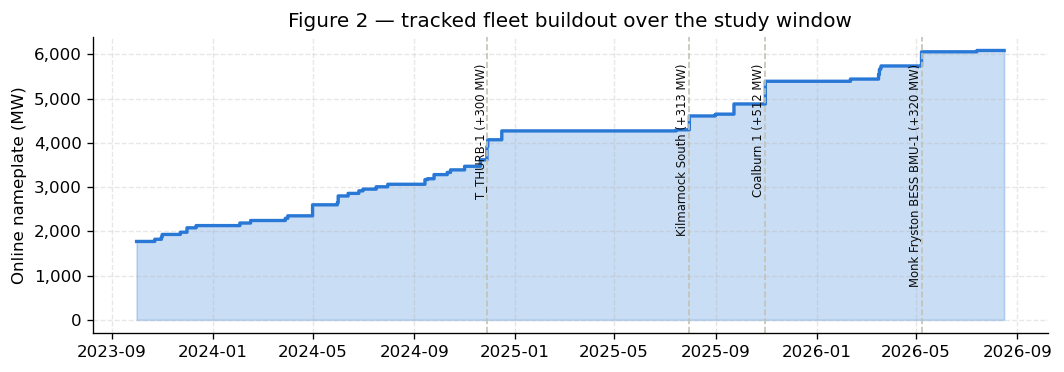

In [4]:
pn = pn.copy()
pn["time"] = pd.to_datetime(pn["time"], utc=True)
pn["date"] = pn["time"].dt.date

span = pn.groupby("site")["date"].agg(first_pn="min", last_pn="max")
span["power_mw"] = span.index.map(SITE_MW)
span["capacity_mwh"] = span.index.map(SITE_MWH)

day_index = pd.DatetimeIndex(sorted(pd.to_datetime(cov["date"]).unique()), name="date").tz_localize("UTC")
online_mw = pd.Series(0.0, index=day_index)
online_n = pd.Series(0, index=day_index)
for site, row in span.iterrows():
    live_days = (day_index.date >= row["first_pn"]) & (day_index.date <= row["last_pn"])
    online_mw[live_days] += row["power_mw"]
    online_n[live_days] += 1

core_cutoff = WINDOW_START + dt.timedelta(days=30)
tail_cutoff = WINDOW_END - dt.timedelta(days=7)
span["core"] = (span["first_pn"] <= core_cutoff) & (span["last_pn"] >= tail_cutoff)
CORE_SITES = sorted(span.index[span["core"]])

print(span.sort_values("power_mw", ascending=False).to_string())
print(f"\nOnline nameplate: {online_mw.iloc[0]:,.0f} MW → {online_mw.iloc[-1]:,.0f} MW "
      f"({online_mw.iloc[-1] / max(online_mw.iloc[0], 1) - 1:+.0%}), "
      f"{int(online_n.iloc[0])} → {int(online_n.iloc[-1])} sites")
print(f"Core panel      : {len(CORE_SITES)} sites, "
      f"{span.loc[span['core'], 'power_mw'].sum():,.0f} MW")

# Figure 2 — tracked fleet buildout.
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.fill_between(online_mw.index, online_mw.values, step="post",
                color=C["da"], alpha=0.25)
ax.step(online_mw.index, online_mw.values, where="post", color=C["da"], lw=2)
for site, row in span.sort_values("power_mw", ascending=False).head(4).iterrows():
    first = pd.Timestamp(row["first_pn"], tz="UTC")
    if first > day_index[0]:
        ax.axvline(first, color=C["ghost"], lw=1, ls="--")
        ax.annotate(f"{site} (+{row['power_mw']:.0f} MW)", (first, online_mw.max() * 0.95),
                    rotation=90, va="top", ha="right", fontsize=7, color=C["ink"])
ax.set_ylabel("Online nameplate (MW)")
ax.set_title("Figure 2 — tracked fleet buildout over the study window")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

## 3. System stress: classification and conditioning sets

Two independent views of stress. The **relative** one (notebook 04's signal) is the top decile
of residual load within the window. The **operator-grade** ones come from Elexon's loss-of-load
probability and de-rated margin prints and from the NESO Capacity Market Notice register — these
are absolute, account for outages, interconnectors and de-rating, and are what the system
operator itself acts on.

The four conditioning sets below define every "under stress" statistic in the rest of the
notebook. Their sizes are printed before any statistic is computed on them, and any set with
fewer than ten members is labelled a **case study** rather than a distribution — a rule fixed
here, before the counts are known.

In [5]:
flags = resilience.classify_periods(system["residual_mw"])

# Latest print per settlement period (shortest horizon wins) — the same rule as
# src.data.preprocess.process_lolpdrm, applied to the store's print-level table.
final = (prints.sort_values(["horizon", "publish_time"], ascending=[True, False])
               .drop_duplicates("time")
               .set_index("time")[["lolp", "drm_mw"]]
               .sort_index())

cmn_issued = cmn[cmn["type_id"] == 1] if not cmn.empty else cmn
cmn_expiry = cmn[cmn["type_id"] == 4] if not cmn.empty else cmn
tiers = resilience.classify_tiers(flags, final, cmn_issued)
grid = tiers.index
known = tiers["tier2_known"]
lolp, drm = tiers["lolp"], tiers["drm_mw"]

lolp_p99 = float(lolp[known].quantile(0.99)) if known.any() else float("nan")
if lolp_p99 > 0:
    C_LOLP = (lolp >= lolp_p99).fillna(False)
    lolp_rule = (f"LoLP ≥ p99 = {lolp_p99:.3e} (top 1% of periods with a print; "
                 "the threshold is a very small positive probability, not zero)")
else:
    C_LOLP = (lolp > 0).fillna(False)
    lolp_rule = "LoLP > 0 (p99 is exactly zero — LoLP is zero in >99% of periods)"

drm_p01 = float(drm[known].quantile(0.01)) if known.any() else float("nan")
C_DRM = (drm <= drm_p01).fillna(False)
C_DRM1000 = (drm < DRM_CRITICAL_MW).fillna(False)
C_CMN = tiers["tier3"].fillna(False)
C_TIER1 = tiers["tier1"].fillna(False)

SETS = {
    "All periods": pd.Series(True, index=grid),
    "Tier 1 (residual decile)": C_TIER1,
    "C_LOLP": C_LOLP,
    "C_DRM (p1)": C_DRM,
    "C_DRM<1GW": C_DRM1000,
    "C_CMN": C_CMN,
}
CRITICAL = (C_LOLP | C_DRM | C_DRM1000).fillna(False)

print(f"Classified periods : {len(grid):,}  ({known.sum():,} with a LoLP/DRM print)")
print(f"LoLP rule          : {lolp_rule}")
print(f"DRM p1             : {drm_p01:,.0f} MW   |   DRM min: {drm.min():,.0f} MW")
print(f"Critical union     : {int(CRITICAL.sum())} periods\n")
print(pd.Series({k: int(v.sum()) for k, v in SETS.items()}, name="periods").to_string())

overlap = pd.DataFrame(
    {a: {b: int((SETS[a] & SETS[b]).sum()) for b in SETS} for a in SETS}
)
print("\nOverlap (periods in both):")
print(overlap.to_string())

tightest = drm.idxmin()
print(f"\nTightest period in window : {tightest:%Y-%m-%d %H:%M} — "
      f"DRM {drm[tightest]:,.0f} MW, LoLP {lolp[tightest]:.1%}")

# Anchor check against the window's Capacity Market Notice evening. Note the
# margin that night was 1,003.5 MW — three megawatts *above* the 1,000 MW line,
# which is why the sub-1GW set is smaller than the notice count suggests and is
# treated as a case study below rather than a distribution.
anchor_cmn = pd.Timestamp("2025-01-08T16:30:00Z")   # the notice's target period
anchor_tight = pd.Timestamp("2025-01-08T17:00:00Z")  # that evening's tightest half-hour
if anchor_tight in grid:
    assert C_CMN[anchor_cmn], "the 2025-01-08 CMN target period should be flagged"
    assert C_LOLP[anchor_tight], "2025-01-08 17:00 should be a top-percentile LoLP period"
    print(f"Anchor OK                 : CMN target {anchor_cmn:%H:%M} flagged; "
          f"{anchor_tight:%H:%M} DRM {drm[anchor_tight]:,.0f} MW, "
          f"LoLP {lolp[anchor_tight]:.1%}")
else:
    print("Anchor 2025-01-08 not in window (dry run) — skipping anchor assertions.")

for name, m in SETS.items():
    n = int(m.fillna(False).sum())
    if 0 < n < MIN_N_DIST:
        print(f"NOTE: {name} has n={n} (< {MIN_N_DIST}) — reported as a case study, "
              "not a distribution.")

Classified periods : 50,447  (50,447 with a LoLP/DRM print)
LoLP rule          : LoLP ≥ p99 = 1.025e-05 (top 1% of periods with a print; the threshold is a very small positive probability, not zero)
DRM p1             : 5,155 MW   |   DRM min: 239 MW
Critical union     : 685 periods

All periods                 50447
Tier 1 (residual decile)     5045
C_LOLP                        505
C_DRM (p1)                    505
C_DRM<1GW                       2
C_CMN                           3

Overlap (periods in both):
                          All periods  Tier 1 (residual decile)  C_LOLP  C_DRM (p1)  C_DRM<1GW  C_CMN
All periods                     50447                      5045     505         505          2      3
Tier 1 (residual decile)         5045                      5045     435         433          2      3
C_LOLP                            505                       435     505         325          2      3
C_DRM (p1)                        505                       433     325    

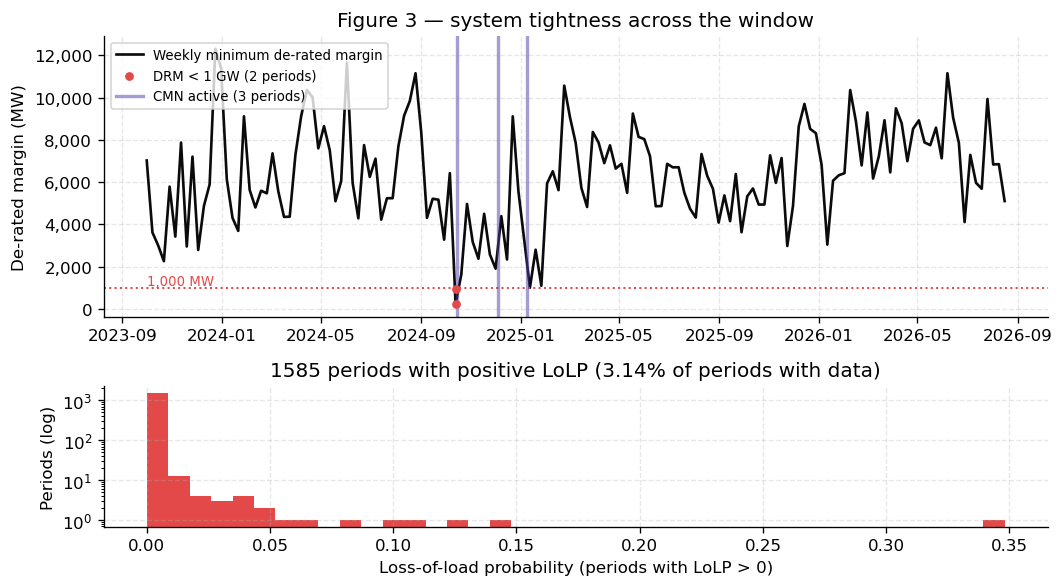

Tight periods by calendar year:
      DRM<1GW  LoLP>0
year                 
2023        0     229
2024        2     660
2025        0     505
2026        0     191


In [6]:
# Figure 3 — where the tight periods actually are.
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
weekly_min = drm.resample("W").min()
ax.plot(weekly_min.index, weekly_min.values, color=C["ink"], lw=1.6,
        label="Weekly minimum de-rated margin")
ax.axhline(DRM_CRITICAL_MW, color=C["cost"], ls=":", lw=1.2)
ax.annotate(f"{DRM_CRITICAL_MW:,.0f} MW", (weekly_min.index[0], DRM_CRITICAL_MW),
            fontsize=8, color=C["cost"], va="bottom")
tight = drm[C_DRM1000]
if len(tight):
    ax.scatter(tight.index, tight.values, s=18, color=C["cost"], zorder=3,
               label=f"DRM < 1 GW ({len(tight)} periods)")
cmn_times = grid[C_CMN]
if len(cmn_times):
    for t in cmn_times:
        ax.axvline(t, color=C["soc"], lw=2, alpha=0.5)
    ax.plot([], [], color=C["soc"], lw=2, alpha=0.5,
            label=f"CMN active ({len(cmn_times)} periods)")
ax.set_ylabel("De-rated margin (MW)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Figure 3 — system tightness across the window")

ax = axes[1]
positive = lolp[lolp > 0]
if len(positive):
    ax.hist(positive.values, bins=40, color=C["cost"])
    ax.set_yscale("log")
    ax.set_xlabel("Loss-of-load probability (periods with LoLP > 0)")
    ax.set_ylabel("Periods (log)")
    ax.set_title(f"{len(positive)} periods with positive LoLP "
                 f"({len(positive) / max(int(known.sum()), 1):.2%} of periods with data)")
else:
    ax.text(0.5, 0.5, "No period with LoLP > 0 in this window",
            ha="center", va="center", transform=ax.transAxes, color=C["ink"])
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

by_winter = pd.DataFrame({
    "DRM<1GW": drm[C_DRM1000].groupby(drm[C_DRM1000].index.year).size(),
    "LoLP>0": lolp[lolp > 0].groupby(lolp[lolp > 0].index.year).size(),
}).fillna(0).astype(int)
by_winter.index.name = "year"
print("Tight periods by calendar year:")
print(by_winter.to_string() if len(by_winter) else "  none")

## 4. RQ1 — Physical availability: is the fleet there when the system needs it?

Three measures per conditioning set, all normalised for fleet growth:

* **Net response** — fleet net MW per MW of online nameplate. Positive = the fleet is
  exporting into the tight period; negative = it is drawing from it.
* **Availability factor** — declared export limit (MELS) per MW online. This is *declared*
  capability, not proven output: it is what the system operator could see as available.
* **State of charge** — inferred from Physical Notifications (never observed), so it carries
  a usability filter and a sensitivity check. The energy behind the power is the whole
  question: a fleet at 20% SoC entering a stress block cannot deliver for long.

In [7]:
for frame in (mels, mils):
    frame["time"] = pd.to_datetime(frame["time"], utc=True)

online_at = pd.Series(online_mw.reindex(grid.normalize()).to_numpy(), index=grid)
fleet_net = pn.groupby("time")["mw"].sum().reindex(grid)
fleet_mel = mels.groupby("time")["mw"].sum().reindex(grid)
fleet_mil = mils.groupby("time")["mw"].sum().reindex(grid)

norm_net = fleet_net / online_at.replace(0, np.nan)
avail_factor = fleet_mel / online_at.replace(0, np.nan)
headroom_mw = fleet_mel - fleet_net.clip(lower=0)


def infer_soc(mw, capacity_mwh, reanchor=False):
    '''Inferred state of charge (fraction) before each period, from PN MW.

    Returns (series, clamp_fraction). The clip at 0/capacity is what keeps the
    integration from drifting away over months; the clamp fraction reports how
    often that safety net was actually load-bearing, which is the diagnostic
    that decides whether a site's inferred SoC is usable at all.
    '''
    vals = np.nan_to_num(mw.to_numpy(dtype=float))
    idx = mw.index
    out = np.empty(len(vals))
    level = 0.5 * capacity_mwh
    clamped = 0
    for i in range(len(vals)):
        if reanchor and idx[i].hour == 4 and idx[i].minute == 0:
            level = 0.5 * capacity_mwh
        out[i] = level
        v = vals[i]
        new = level + (max(-v, 0.0) * ETA_C - max(v, 0.0) / ETA_D) * HH
        if new < 0.0 or new > capacity_mwh:
            clamped += 1
        level = min(max(new, 0.0), capacity_mwh)
    return pd.Series(out / capacity_mwh, index=idx), clamped / max(len(vals), 1)


wide = pn.pivot_table(index="time", columns="site", values="mw", aggfunc="sum")
soc_cols, soc_anchor_cols, diag_rows = {}, {}, []
skipped_no_mwh: list[str] = []
for site in wide.columns:
    cap = SITE_MWH.get(site)
    # `not cap` does not reject a nan — nan is truthy — so unknown energy
    # capacity has to be tested for explicitly. Without this, a census site with
    # no published duration would divide through by nan and contribute a column
    # of silent nulls to the fleet state-of-charge instead of being excluded.
    if cap is None or cap != cap or cap <= 0:
        skipped_no_mwh.append(site)
        continue
    lo = pd.Timestamp(span.loc[site, "first_pn"], tz="UTC")
    hi = pd.Timestamp(span.loc[site, "last_pn"], tz="UTC") + pd.Timedelta(days=1)
    sub = grid[(grid >= lo) & (grid < hi)]
    if len(sub) < 48:
        continue
    series = wide[site].reindex(sub).fillna(0.0)
    soc, clamp = infer_soc(series, cap)
    soc_anchor, _ = infer_soc(series, cap, reanchor=True)
    discharge_mwh = series.clip(lower=0).sum() * HH
    cycles_day = discharge_mwh / cap / (len(sub) * HH / 24.0)
    usable = (cycles_day >= CYCLES_MIN) and (clamp <= SOC_CLAMP_MAX)
    soc_cols[site], soc_anchor_cols[site] = soc, soc_anchor
    diag_rows.append({"site": site, "capacity_mwh": cap, "cycles_per_day": cycles_day,
                      "clamp_frac": clamp, "usable_soc": usable, "periods": len(sub)})

soc_diag = pd.DataFrame(diag_rows).set_index("site").sort_values("cycles_per_day",
                                                                ascending=False)
USABLE_SOC = list(soc_diag.index[soc_diag["usable_soc"]])
soc_df = pd.DataFrame(soc_cols)
soc_anchor_df = pd.DataFrame(soc_anchor_cols)


def _fleet_soc(frame):
    if not USABLE_SOC:
        return pd.Series(index=grid, dtype=float)
    sub = frame[USABLE_SOC].reindex(grid)
    w = pd.Series({s: SITE_MWH[s] for s in USABLE_SOC})
    num = sub.mul(w, axis=1).sum(axis=1, min_count=1)
    den = sub.notna().mul(w, axis=1).sum(axis=1)
    return num / den.replace(0, np.nan)


fleet_soc = _fleet_soc(soc_df)
fleet_soc_anchor = _fleet_soc(soc_anchor_df)

if skipped_no_mwh:
    mw_skipped = sum(SITE_MW.get(s, 0.0) for s in skipped_no_mwh)
    print(f"State of charge is undefined for {len(skipped_no_mwh)} of {len(wide.columns)} "
          f"active sites ({mw_skipped:,.0f} MW) with no published energy capacity. "
          f"They are excluded from every SoC and cycles figure and remain in all "
          f"MW-normalised ones.\n")

print(soc_diag.round(3).to_string())
print(f"\nSoC-usable sites: {len(USABLE_SOC)}/{len(soc_diag)} "
      f"({', '.join(USABLE_SOC) if USABLE_SOC else 'none'})")
if len(USABLE_SOC) == 0:
    skip("no site passed the SoC usability filter — SoC statistics below are unavailable")
else:
    corr = fleet_soc.corr(fleet_soc_anchor)
    print(f"Primary vs daily-re-anchored fleet SoC: correlation {corr:+.2f}, "
          f"mean gap {abs(fleet_soc - fleet_soc_anchor).mean():.1%}")

State of charge is undefined for 41 of 82 active sites (2,262 MW) with no published energy capacity. They are excluded from every SoC and cycles figure and remain in all MW-normalised ones.

                               capacity_mwh  cycles_per_day  clamp_frac  usable_soc  periods
site                                                                                        
Erskine BESS                         30.000           1.699       0.227        True     1632
Roaring Hill BESS                    74.985           1.564       0.218        True    46991
Blackhillock                        400.000           1.553       0.323        True    40224
Holes Bay Battery                    10.000           1.462       0.165        True    50447
Little Raith BESS                    98.000           1.416       0.251        True    47903
North Tawton BESS                    30.000           1.412       0.196        True     7248
Pivot Power Coventry                 80.000           1.213      

RQ1 — fleet response by conditioning set
                              n  net_MW_per_MW  median_MW_per_MW  discharging_%  avail_factor  mean_SoC  mean_SoC_anchored
set                                                                                                                       
All periods               50447          0.000            -0.006          0.448         0.305     0.392              0.406
Tier 1 (residual decile)   5045          0.052             0.027          0.675         0.320     0.398              0.401
C_LOLP                      505          0.120             0.120          0.915         0.300     0.374              0.355
C_DRM (p1)                  505          0.107             0.099          0.889         0.319     0.399              0.389
C_DRM<1GW                     2          0.118             0.118          1.000         0.237     0.531              0.438
C_CMN                         3          0.122             0.163          1.000         0.300     

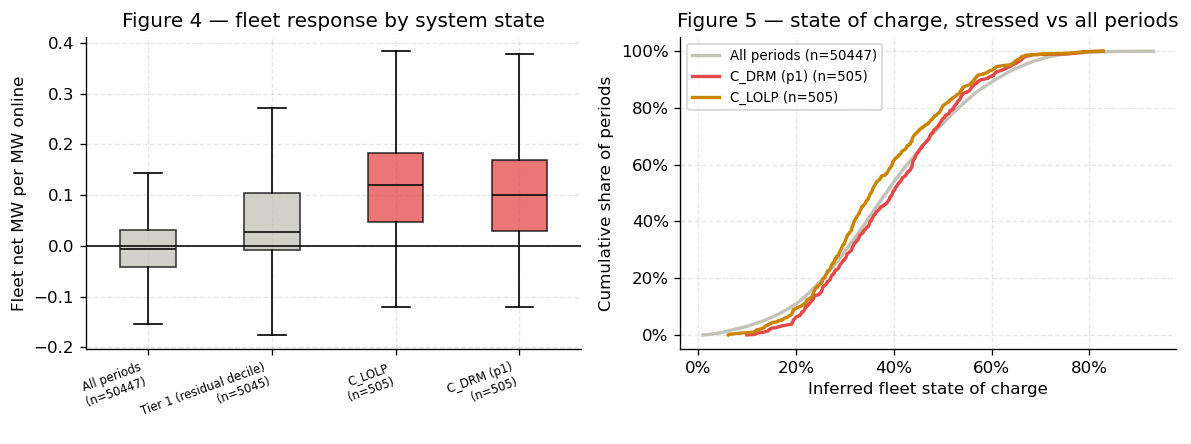

In [8]:
def set_stats(mask, name):
    m = mask.fillna(False)
    n = int(m.sum())
    if n == 0:
        return {"set": name, "n": 0}
    return {
        "set": name,
        "n": n,
        "net_MW_per_MW": float(norm_net[m].mean()),
        "median_MW_per_MW": float(norm_net[m].median()),
        "discharging_%": float((fleet_net[m] > 0).mean()),
        "avail_factor": float(avail_factor[m].mean()),
        "mean_SoC": float(fleet_soc[m].mean()) if len(USABLE_SOC) else np.nan,
        "mean_SoC_anchored": float(fleet_soc_anchor[m].mean()) if len(USABLE_SOC) else np.nan,
    }


rq1 = pd.DataFrame([set_stats(m, k) for k, m in SETS.items()]).set_index("set")
print("RQ1 — fleet response by conditioning set")
print(rq1.round(3).to_string())

baseline = rq1.loc["All periods"]
for name in ("C_LOLP", "C_DRM (p1)", "C_DRM<1GW", "C_CMN"):
    row = rq1.loc[name]
    if row["n"] == 0:
        skip(f"{name} is empty in this window")
        continue
    tag = " [case study]" if row["n"] < MIN_N_DIST else ""
    print(f"\n{name} (n={int(row['n'])}){tag}: net {row['net_MW_per_MW']:+.3f} MW/MW online "
          f"vs {baseline['net_MW_per_MW']:+.3f} baseline · "
          f"discharging in {row['discharging_%']:.0%} of periods · "
          f"availability {row['avail_factor']:.0%}"
          + (f" · mean SoC {row['mean_SoC']:.0%}" if len(USABLE_SOC) else ""))

plot_sets = {k: v for k, v in SETS.items() if int(v.fillna(False).sum()) >= 5}
if len(plot_sets) < 2:
    skip("fewer than two conditioning sets have ≥5 periods — no distribution figure")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    data = [norm_net[m.fillna(False)].dropna().values for m in plot_sets.values()]
    bp = axes[0].boxplot(data, vert=True, patch_artist=True, showfliers=False,
                         medianprops={"color": C["ink"]})
    for patch, name in zip(bp["boxes"], plot_sets):
        patch.set_facecolor(C["cost"] if name not in ("All periods", "Tier 1 (residual decile)")
                            else C["ghost"])
        patch.set_alpha(0.75)
    axes[0].axhline(0, color=C["ink"], lw=1)
    axes[0].set_xticklabels([f"{k}\n(n={int(v.fillna(False).sum())})" for k, v in plot_sets.items()],
                            rotation=20, ha="right", fontsize=7)
    axes[0].set_ylabel("Fleet net MW per MW online")
    axes[0].set_title("Figure 4 — fleet response by system state")

    ax = axes[1]
    if len(USABLE_SOC):
        for name, colour in (("All periods", C["ghost"]), ("C_DRM (p1)", C["cost"]),
                             ("C_LOLP", C["mid"])):
            m = SETS[name].fillna(False)
            vals = fleet_soc[m].dropna().sort_values()
            if len(vals) < 5:
                continue
            ax.plot(vals.values, np.linspace(0, 1, len(vals)), color=colour, lw=2,
                    label=f"{name} (n={len(vals)})")
        ax.set_xlabel("Inferred fleet state of charge")
        ax.set_ylabel("Cumulative share of periods")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.legend(fontsize=8)
        ax.set_title("Figure 5 — state of charge, stressed vs all periods")
    else:
        ax.text(0.5, 0.5, "No SoC-usable sites", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

3 Capacity Market Notice(s) issued in the window:
 notice                    issued                    target                 cancelled  cancelled_h_before_target
     37 2025-01-08 12:01:14+00:00 2025-01-08 16:30:00+00:00 2025-01-08 12:32:49+00:00                   3.953056
     35 2024-12-03 13:02:20+00:00 2024-12-03 17:30:00+00:00 2024-12-03 14:33:47+00:00                   2.936944
     33 2024-10-14 11:03:45+00:00 2024-10-14 15:30:00+00:00 2024-10-14 13:05:07+00:00                   2.414722

Still standing when the targeted period arrived: 0/3.  Every notice was withdrawn before delivery — the declared-shortfall tier records a *warning*, not a realised shortfall.


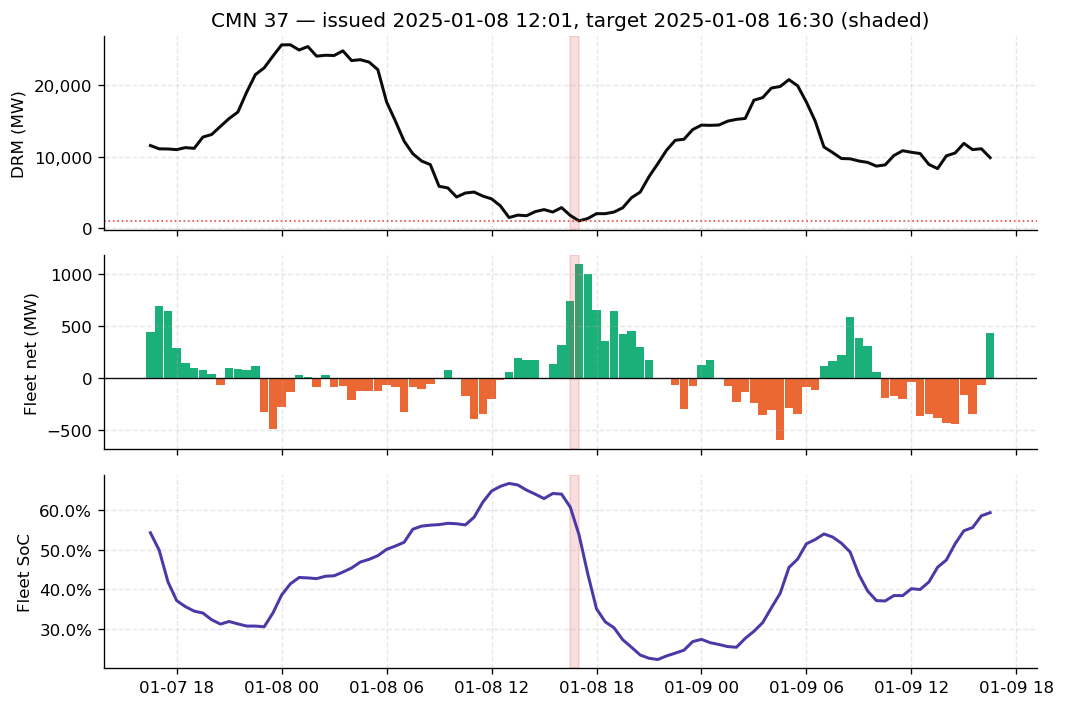

  During the notice: fleet net +735 MW (+0.17 per MW online), SoC 61%


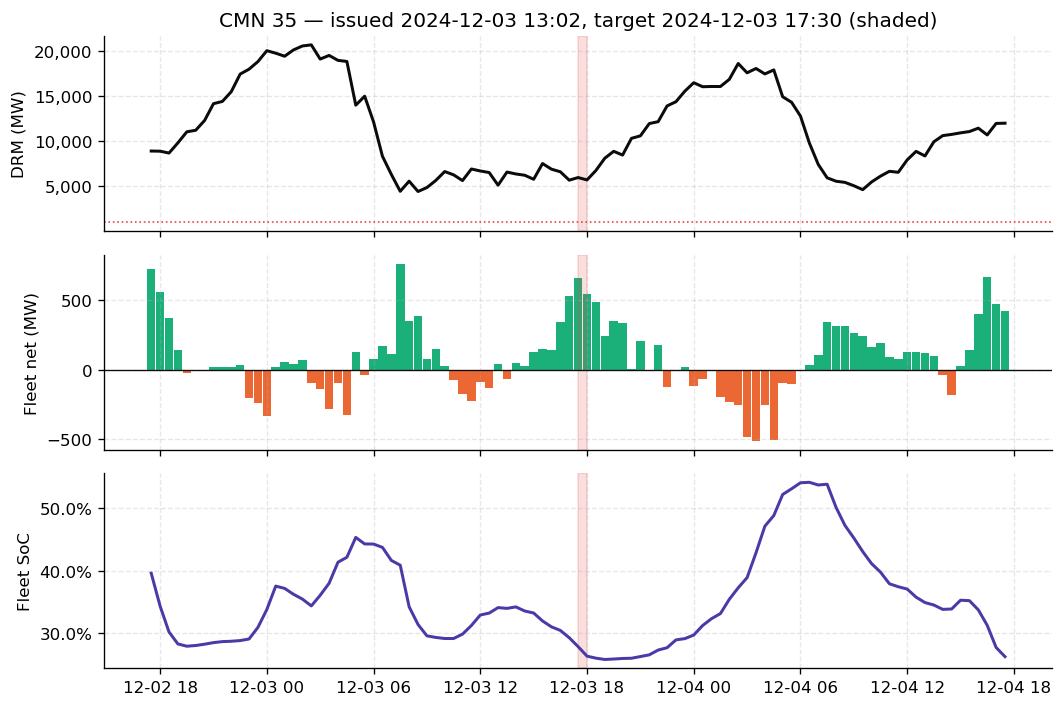

  During the notice: fleet net +663 MW (+0.16 per MW online), SoC 28%


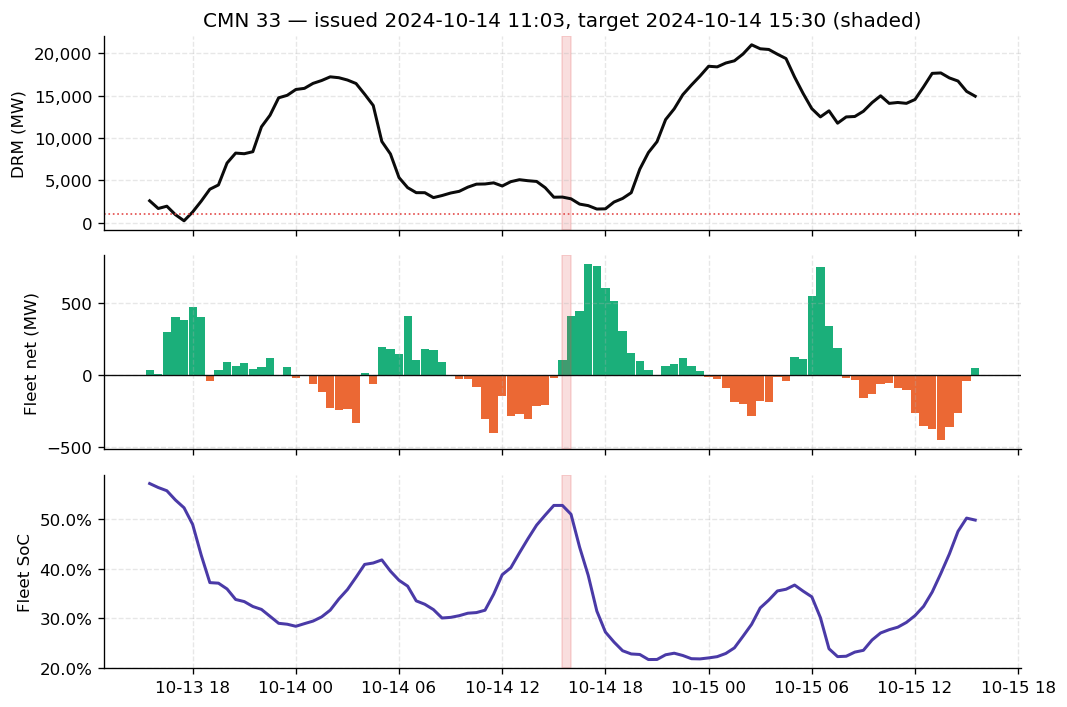

  During the notice: fleet net +106 MW (+0.03 per MW online), SoC 53%


In [9]:
# Capacity Market Notices are rare by design, so these are exhibits, not statistics.
if cmn_issued.empty:
    skip("no Capacity Market Notice in the window — nothing to exhibit")
else:
    # Pair each issued notice with the expiry covering the same target period:
    # whether a notice was still standing at delivery is the whole question.
    survived = 0
    rows = []
    for _, notice in cmn_issued.iterrows():
        match = cmn_expiry[cmn_expiry["start_utc"] == notice["start_utc"]]
        cancelled_at = match["posted_utc"].min() if not match.empty else pd.NaT
        lead_h = ((notice["start_utc"] - cancelled_at).total_seconds() / 3600
                  if pd.notna(cancelled_at) else np.nan)
        survived += int(pd.isna(cancelled_at))
        rows.append({"notice": int(notice["notice_id"]),
                     "issued": notice["posted_utc"], "target": notice["start_utc"],
                     "cancelled": cancelled_at, "cancelled_h_before_target": lead_h})
    cmn_life = pd.DataFrame(rows)
    print(f"{len(cmn_issued)} Capacity Market Notice(s) issued in the window:")
    print(cmn_life.to_string(index=False))
    print(f"\nStill standing when the targeted period arrived: {survived}/{len(cmn_issued)}."
          + ("  Every notice was withdrawn before delivery — the declared-shortfall tier "
             "records a *warning*, not a realised shortfall." if survived == 0 else ""))
    for _, notice in cmn_issued.iterrows():
        centre = notice["start_utc"]
        lo, hi = centre - pd.Timedelta(hours=24), centre + pd.Timedelta(hours=24)
        win = grid[(grid >= lo) & (grid <= hi)]
        if len(win) < 4:
            continue
        fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1, 1]})
        axes[0].plot(win, drm.reindex(win).values, color=C["ink"], lw=1.8)
        axes[0].axhline(DRM_CRITICAL_MW, color=C["cost"], ls=":", lw=1)
        axes[0].set_ylabel("DRM (MW)")
        axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
        axes[1].bar(win, fleet_net.reindex(win).values, width=0.02,
                    color=[C["discharge"] if v > 0 else C["charge"]
                           for v in fleet_net.reindex(win).fillna(0)])
        axes[1].axhline(0, color=C["ink"], lw=0.8)
        axes[1].set_ylabel("Fleet net (MW)")
        if len(USABLE_SOC):
            axes[2].plot(win, fleet_soc.reindex(win).values, color=C["soc"], lw=1.8)
            axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        axes[2].set_ylabel("Fleet SoC")
        end = notice["end_utc"] if pd.notna(notice["end_utc"]) else centre + pd.Timedelta(minutes=30)
        for ax in axes:
            ax.axvspan(centre, end, color=C["cost"], alpha=0.18)
        axes[0].set_title(f"CMN {int(notice['notice_id'])} — issued "
                          f"{notice['posted_utc']:%Y-%m-%d %H:%M}, target "
                          f"{centre:%Y-%m-%d %H:%M} (shaded)")
        plt.tight_layout()
        plt.show()

        during = grid[(grid >= centre) & (grid < end)]
        if len(during):
            print(f"  During the notice: fleet net {fleet_net.reindex(during).mean():+,.0f} MW "
                  f"({norm_net.reindex(during).mean():+.2f} per MW online)"
                  + (f", SoC {fleet_soc.reindex(during).mean():.0%}" if len(USABLE_SOC) else ""))

## 4b. Trend — is the fleet's response to tightness changing?

Section 4 answers *whether* the fleet shows up under stress. It says nothing about
**direction of travel**, and over a window in which the fleet tripled and its revenue stack
was rebuilt, that is the more useful question for anyone deciding where GB storage is headed.

Two things make a naive trend chart meaningless here, so both are controlled for.

**Seasonality.** Operator-grade scarcity is a winter phenomenon: C_LOLP periods per quarter
range from 2 to 183 across this window, so a quarterly line drawn through them would be
measuring the weather. The continuous chart therefore conditions on each quarter's **own**
tightest decile of residual load — self-normalising by construction, and n ≈ 440 every
quarter rather than single digits.

**Composition.** Active sites grow from 36 to 82 here. A rising line could simply be newer
batteries behaving differently from older ones, which is a fact about commissioning, not about
behaviour. Every series is therefore normalised per MW online *and* shown twice: once for the
full census, once for a **fixed panel** of sites present across the entire window. If the two
disagree, the trend is composition; if they agree, it is behaviour.

The operator-grade view is kept as well, but as three winter bars with error bars rather than
a line — 104, 273 and 81 scarcity periods is three snapshots, not a trend, and drawing a line
through them would claim more than the data can carry.

In [10]:
def quarterly_tight_response(sites=None, decile=0.90, min_n=50):
    """Fleet response during each quarter's own tightest decile of residual load.

    Conditioning within the quarter is what makes this comparable across the
    window: "tight" always means tight *for that quarter*, so winter does not
    masquerade as a trend. Returns one row per quarter with a standard error,
    because quarters differ in length and the last one is partial.
    """
    frame = pn if sites is None else pn[pn["site"].isin(sites)]

    # Online MW is recomputed for whichever subset is passed, so the core panel
    # is normalised by its own nameplate rather than the whole fleet's.
    sub_span = frame.groupby("site")["date"].agg(first="min", last="max")
    days = pd.DatetimeIndex(sorted(frame["date"].unique()), tz="UTC")
    online = pd.Series(0.0, index=days)
    for site, row in sub_span.iterrows():
        live = (days.date >= row["first"]) & (days.date <= row["last"])
        online[live] += SITE_MW.get(site, 0.0)

    net = frame.groupby("time")["mw"].sum()
    idx = net.index
    online_here = pd.Series(online.reindex(idx.normalize()).to_numpy(), index=idx)
    frame_df = pd.DataFrame({
        "norm": net / online_here.replace(0, np.nan),
        "residual": system["residual_mw"].reindex(idx),
    }).dropna()
    # Explicit UTC: to_period would otherwise drop the timezone with a warning.
    frame_df["quarter"] = (
        frame_df.index.tz_convert("UTC").tz_localize(None).to_period("Q")
    )

    rows = []
    for quarter, group in frame_df.groupby("quarter"):
        tight = group[group["residual"] >= group["residual"].quantile(decile)]
        if len(tight) < min_n:
            continue
        rows.append({
            "quarter": str(quarter),
            "n": len(tight),
            "net": tight["norm"].mean(),
            "se": tight["norm"].std() / np.sqrt(len(tight)),
            "discharging": 100.0 * (tight["norm"] > 0).mean(),
        })
    return pd.DataFrame(rows)


trend_all = quarterly_tight_response()
trend_core = quarterly_tight_response(CORE_SITES)

slope = lambda t: np.polyfit(np.arange(len(t)), t["net"], 1)[0]
print(f"Full census     : {trend_all['net'].iloc[0]:.3f} → {trend_all['net'].iloc[-1]:.3f} "
      f"MW/MW   ({slope(trend_all) * 4:+.3f} per year)")
print(f"Fixed core panel: {trend_core['net'].iloc[0]:.3f} → {trend_core['net'].iloc[-1]:.3f} "
      f"MW/MW   ({slope(trend_core) * 4:+.3f} per year)   "
      f"[{len(CORE_SITES)} sites, {sum(SITE_MW.get(s, 0) for s in CORE_SITES):,.0f} MW]")
print("\nThe two slopes agreeing is the result: the same batteries respond more than they "
      "used to,\nso the trend is behaviour rather than newer sites diluting older ones.\n")
trend_all[["quarter", "n", "net", "se", "discharging"]].round(3)

Full census     : 0.062 → 0.127 MW/MW   (+0.018 per year)
Fixed core panel: 0.063 → 0.126 MW/MW   (+0.014 per year)   [38 sites, 1,871 MW]

The two slopes agreeing is the result: the same batteries respond more than they used to,
so the trend is behaviour rather than newer sites diluting older ones.



,quarter,n,net,se,discharging
0,2023Q4,442,0.062,0.005,62.670
1,2024Q1,437,0.073,0.006,61.556
2,2024Q2,437,0.068,0.004,78.490
3,2024Q3,442,0.060,0.003,77.602
4,2024Q4,442,0.060,0.003,80.995
5,2025Q1,432,0.062,0.004,79.861
6,2025Q2,437,0.069,0.004,75.973
7,2025Q3,442,0.075,0.003,85.973
8,2025Q4,442,0.073,0.004,82.579
9,2026Q1,432,0.082,0.005,78.009


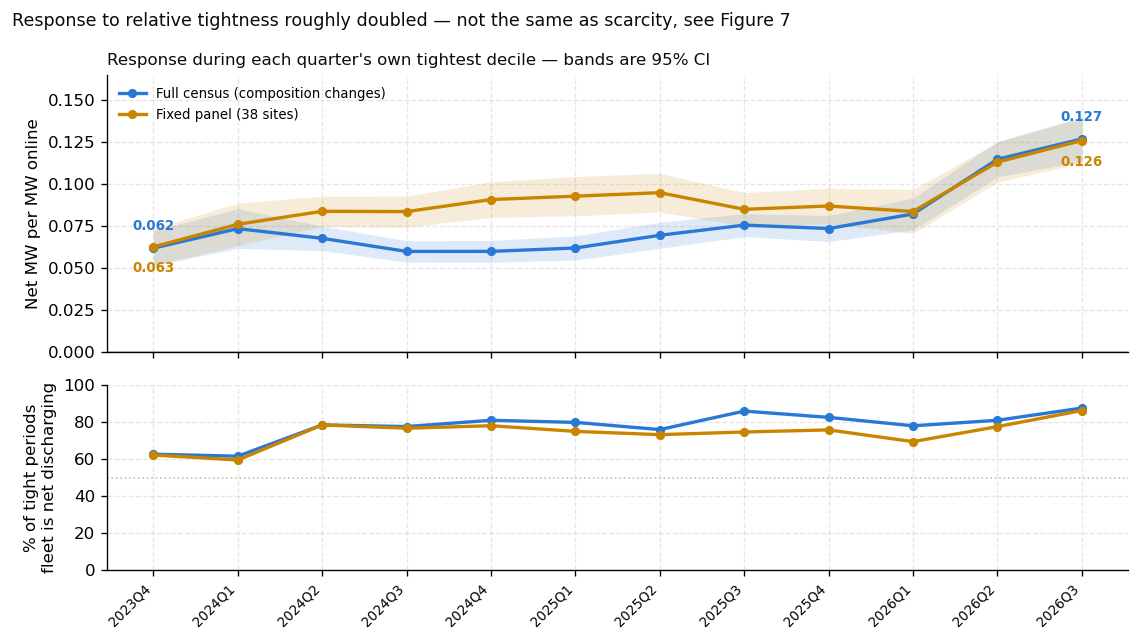

Final quarter is partial (n=226 vs ~438 typical), so read its level, not its slope.


In [11]:
# Figure 6 — direction of travel, with composition held constant as a control.
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.4), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})
x = np.arange(len(trend_all))

ax = axes[0]
for frame, colour, label in ((trend_all, C["da"], "Full census (composition changes)"),
                             (trend_core, C["mid"], f"Fixed panel ({len(CORE_SITES)} sites)")):
    ax.plot(x, frame["net"], color=colour, lw=2, marker="o", ms=4.5, label=label, zorder=3)
    ax.fill_between(x, frame["net"] - 1.96 * frame["se"], frame["net"] + 1.96 * frame["se"],
                    color=colour, alpha=0.15, lw=0, zorder=2)
ax.axhline(0, color=C["ghost"], lw=1, zorder=1)
# Label the endpoints only — a number on every point would bury the shape.
# Offsets alternate so the two series' endpoint labels cannot sit on top of
# each other where the lines converge.
for frame, colour, dy in ((trend_all, C["da"], 11), (trend_core, C["mid"], -15)):
    for i in (0, len(frame) - 1):
        ax.annotate(f"{frame['net'].iloc[i]:.3f}", (x[i], frame["net"].iloc[i]),
                    xytext=(0, dy), textcoords="offset points", ha="center",
                    fontsize=8, color=colour, fontweight="bold")
ax.set_ylabel("Net MW per MW online")
ax.set_ylim(0, max(trend_all["net"].max(), trend_core["net"].max()) * 1.30)
ax.set_title("Response during each quarter's own tightest decile — bands are 95% CI",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = axes[1]
ax.plot(x, trend_all["discharging"], color=C["da"], lw=2, marker="o", ms=4.5, zorder=3)
ax.plot(x, trend_core["discharging"], color=C["mid"], lw=2, marker="o", ms=4.5, zorder=3)
ax.set_ylim(0, 100)
ax.set_ylabel("% of tight periods\nfleet is net discharging")
ax.set_xticks(x, trend_all["quarter"], rotation=45, ha="right", fontsize=8)
ax.axhline(50, color=C["ghost"], lw=1, ls=":", zorder=1)

fig.suptitle("Response to relative tightness roughly doubled — not the same as scarcity, see Figure 7",
             fontsize=10.5, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

print(f"Final quarter is partial (n={int(trend_all['n'].iloc[-1])} vs ~{int(trend_all['n'].iloc[:-1].mean())} "
      f"typical), so read its level, not its slope.")

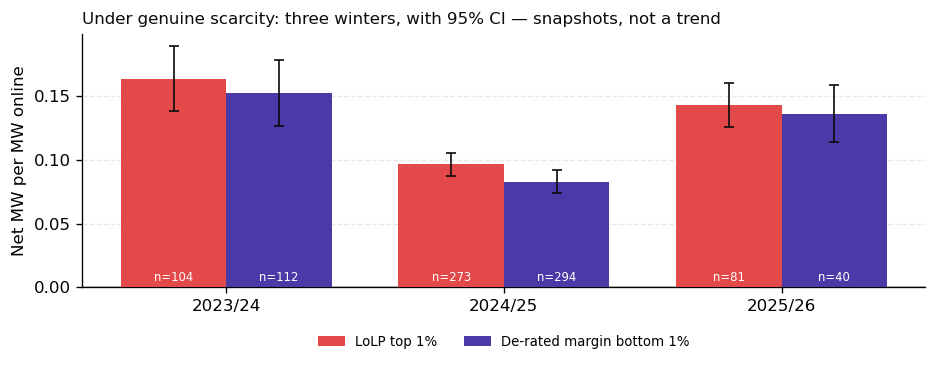

'                  measure  winter   n   net    se\n              LoLP top 1% 2023/24 104 0.164 0.013\n              LoLP top 1% 2024/25 273 0.097 0.005\n              LoLP top 1% 2025/26  81 0.143 0.009\nDe-rated margin bottom 1% 2023/24 112 0.152 0.013\nDe-rated margin bottom 1% 2024/25 294 0.083 0.005\nDe-rated margin bottom 1% 2025/26  40 0.136 0.011'

In [12]:
# Figure 7 — the operator-grade view: three winters, not a trend line.
winter_of = lambda idx: np.where(idx.month >= 10, idx.year,
                                 np.where(idx.month <= 3, idx.year - 1, np.nan))

winter = pd.Series(winter_of(grid), index=grid)
rows = []
for label, mask in (("LoLP top 1%", C_LOLP), ("De-rated margin bottom 1%", C_DRM)):
    m = mask.fillna(False)
    for yr, grp in norm_net[m].groupby(winter[m]):
        if pd.isna(yr) or len(grp) < 20:
            continue
        rows.append({"measure": label, "winter": f"{int(yr)}/{str(int(yr) + 1)[2:]}",
                     "n": len(grp), "net": grp.mean(),
                     "se": grp.std() / np.sqrt(len(grp))})
winters = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3.2))
labels = sorted(winters["winter"].unique())
xw = np.arange(len(labels))
width = 0.38
for k, (measure, colour) in enumerate((("LoLP top 1%", C["cost"]),
                                       ("De-rated margin bottom 1%", C["soc"]))):
    sub = winters[winters["measure"] == measure].set_index("winter").reindex(labels)
    ax.bar(xw + (k - 0.5) * width, sub["net"], width=width, color=colour, label=measure,
           yerr=1.96 * sub["se"], capsize=3,
           error_kw={"lw": 1, "ecolor": C["ink"]}, zorder=3)
    for i, (v, n) in enumerate(zip(sub["net"], sub["n"])):
        if pd.notna(v):
            ax.annotate(f"n={int(n)}", (xw[i] + (k - 0.5) * width, 0), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=7, color="white")

ax.set_xticks(xw, labels)
ax.set_ylabel("Net MW per MW online")
ax.axhline(0, color=C["ghost"], lw=1)
ax.grid(axis="x", visible=False)
ax.set_title("Under genuine scarcity: three winters, with 95% CI — snapshots, not a trend",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.14))
plt.tight_layout()
plt.show()

winters.round(3).to_string(index=False)

**The two views disagree, and the disagreement is the interesting part.**

Conditioned on *relative* tightness, the trend is unambiguous and composition-robust: the same
batteries now export about twice as much per MW online into their quarter's tightest periods
as in late 2023, and are net discharging in those periods far more consistently.

Conditioned on *absolute* scarcity, there is no such trend. The three winters run 0.164 →
0.097 → 0.143 MW/MW — a pronounced dip in 2024/25 that sits well outside its confidence
interval, not noise.

The most likely reconciliation is that the two are measuring different things, and the winter
figure is partly measuring the winters. 2024/25 carried 273 qualifying LoLP periods against
104 in 2023/24 and 81 in 2025/26 — roughly two and a half times as much scarcity — and the
fleet's average response was about 40% lower. That is what a duration-limited asset should
look like: a one- to two-hour battery cannot be near full for every event in a winter that
keeps producing them, so response per event falls as events multiply. On that reading the
fleet is not becoming less reliable in scarcity; it is running into its energy, and a mild
winter flatters it.

**What this establishes and what it does not.** It establishes that behaviour changed under
relative tightness, and that the change is not a composition artefact. It does **not**
establish that the fleet has become more dependable when the system is genuinely short —
the operator-grade series does not support that, and anyone quoting the rising line as
evidence of scarcity reliability would be quoting the wrong figure.

The step between 2026Q1 and 2026Q2 is also large and coincides with the rebuilding of GB's
response and reserve markets, in which per-unit ancillary revenue moved onto the Enduring
Auction Capability platform and wholesale/BM spreads widened. A battery discharging into
tightness because the spread finally pays for it is indistinguishable here from one doing so
for any other reason. Correlation with a market redesign is a reason for caution, not a
mechanism.

## 5. RQ2 — Stress modification: does the fleet relieve or deepen tight margins?

The sharpest version of the question: when the de-rated margin is critically thin, is the
battery fleet a **supplier** or a **load**? Every half-hour the fleet spends charging while
the margin is under 1 GW is a half-hour it is subtracting from the very margin the system is
short of — "cannibalistic" charging.

Fleet net MW is also expressed as a share of the margin itself, which is the number that says
whether the fleet's behaviour is material to the tightness or merely coincident with it.

RQ2 — fleet behaviour by de-rated-margin band
              n  mean_net_MW  mean_MW_per_MW  charging_share  net_pct_of_DRM
band                                                                        
<1,000      2.0      392.283           0.118           0.000           1.010
1–2k       15.0      552.831           0.141           0.000           0.365
2–4k      193.0      398.401           0.118           0.083           0.118
4–7k     1372.0      303.673           0.081           0.198           0.034
>7k     48862.0       -5.557          -0.003           0.564          -0.001

Tightest band (<1,000 MW, n=2, case study): fleet net +392 MW, charging in 0% of periods, median contribution +101.0% of the margin itself.
  Sub-1GW margins are near-unheard-of in GB: read the band above as an anecdote and the percentile sets as the evidence.

Tightest DRM decile (n=5,045, DRM ≤ 9,577 MW): fleet net +247 MW, charging in 27% of periods.


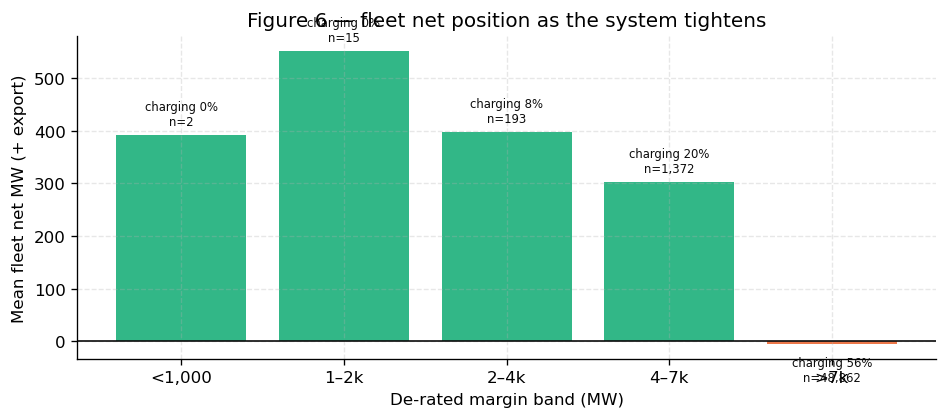

In [13]:
band_df = pd.DataFrame({"drm": drm, "net": fleet_net, "norm": norm_net,
                        "avail": avail_factor}).dropna(subset=["drm", "net"])
if band_df.empty:
    skip("no period has both a DRM print and fleet PN data")
    rq2 = pd.DataFrame()
else:
    band_df["band"] = pd.cut(band_df["drm"], DRM_BANDS, labels=DRM_BAND_LABELS, right=False)
    rq2 = band_df.groupby("band", observed=False).apply(
        lambda g: pd.Series({
            "n": len(g),
            "mean_net_MW": g["net"].mean(),
            "mean_MW_per_MW": g["norm"].mean(),
            "charging_share": (g["net"] < 0).mean(),
            "net_pct_of_DRM": (g["net"] / g["drm"]).median(),
        }), include_groups=False)
    print("RQ2 — fleet behaviour by de-rated-margin band")
    print(rq2.round(3).to_string())

    tight_band = rq2.iloc[0]
    if tight_band["n"] == 0:
        skip("no period with DRM < 1,000 MW — the tightest band is empty in this window")
    else:
        kind = "case study" if tight_band["n"] < MIN_N_DIST else "distribution"
        print(f"\nTightest band (<1,000 MW, n={int(tight_band['n'])}, {kind}): fleet net "
              f"{tight_band['mean_net_MW']:+,.0f} MW, charging in "
              f"{tight_band['charging_share']:.0%} of periods, median contribution "
              f"{tight_band['net_pct_of_DRM']:+.1%} of the margin itself.")
        if tight_band["n"] < MIN_N_DIST:
            print("  Sub-1GW margins are near-unheard-of in GB: read the band above as an "
                  "anecdote and the percentile sets as the evidence.")
        band_df["decile"] = pd.qcut(band_df["drm"], 10, labels=False, duplicates="drop")
        tightest_decile = band_df[band_df["decile"] == 0]
        print(f"\nTightest DRM decile (n={len(tightest_decile):,}, DRM ≤ "
              f"{tightest_decile['drm'].max():,.0f} MW): fleet net "
              f"{tightest_decile['net'].mean():+,.0f} MW, charging in "
              f"{(tightest_decile['net'] < 0).mean():.0%} of periods.")

    plot = rq2[rq2["n"] > 0]
    if len(plot):
        fig, ax = plt.subplots(figsize=(8, 3.6))
        colours = [C["discharge"] if v >= 0 else C["charge"] for v in plot["mean_net_MW"]]
        bars = ax.bar(range(len(plot)), plot["mean_net_MW"].values, color=colours, alpha=0.9)
        for i, (_, row) in enumerate(plot.iterrows()):
            ax.annotate(f"charging {row['charging_share']:.0%}\nn={int(row['n']):,}",
                        (i, row["mean_net_MW"]), textcoords="offset points",
                        xytext=(0, 6 if row["mean_net_MW"] >= 0 else -22),
                        ha="center", fontsize=7, color=C["ink"])
        ax.axhline(0, color=C["ink"], lw=1)
        ax.set_xticks(range(len(plot)))
        ax.set_xticklabels(plot.index.astype(str))
        ax.set_xlabel("De-rated margin band (MW)")
        ax.set_ylabel("Mean fleet net MW (+ export)")
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
        ax.set_title("Figure 6 — fleet net position as the system tightens")
        plt.tight_layout()
        plt.show()

## 6. RQ3 — Dynamic foresight: does the fleet see it coming?

Elexon publishes each settlement period's loss-of-load probability and de-rated margin five
times, at roughly 12, 8, 4, 2 and 1 hours ahead. That gives two separable questions:

1. **Was the tightness visible in advance?** The earliest horizon whose print already crossed
   the critical threshold is the hours of warning the market had.
2. **Did behaviour change once it was visible?** State of charge and dispatch running into a
   critical period, against matched control periods (same half-hour of day, same month, on
   days with no critical period at all).

**Read this as association, not reaction.** Elexon serves only the *final* Physical
Notification for a period — the revision history that would show an operator re-planning is
not published — so what follows compares realised dispatch, and cannot prove the forecast
caused it.

Critical periods with prints: 685
Visible at some horizon      : 654 (95%)
Median warning               : 12 h ahead

Earliest horizon that already crossed the threshold:
warning_h
12.0    534
8.0      33
4.0      42
2.0      32
1.0      13


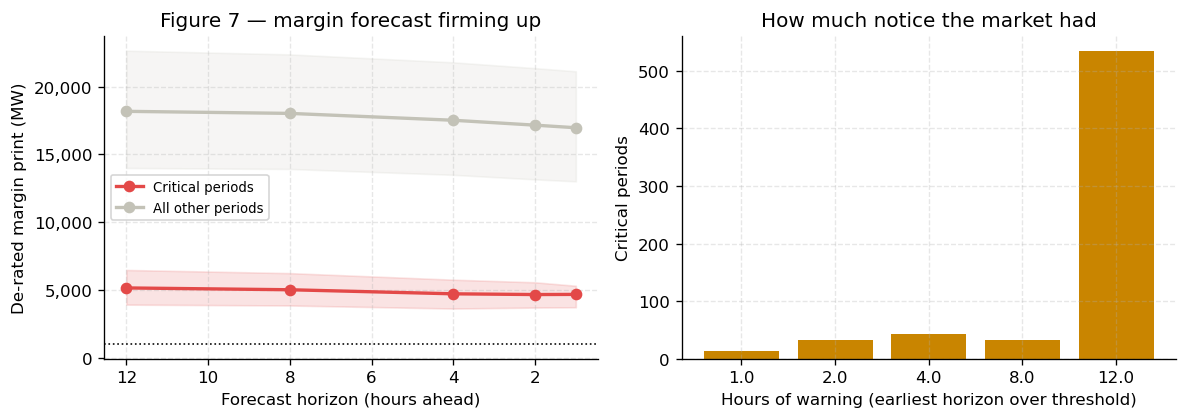

In [14]:
h_drm = prints.pivot_table(index="time", columns="horizon", values="drm_mw", aggfunc="last")
h_lolp = prints.pivot_table(index="time", columns="horizon", values="lolp", aggfunc="last")
HORIZONS = sorted([h for h in h_drm.columns], reverse=True)

crit_times = grid[CRITICAL]
if len(crit_times) == 0:
    skip("no critical period in this window — foresight analysis unavailable")
    warning_h = pd.Series(dtype=float)
else:
    rows = []
    for t in crit_times:
        if t not in h_drm.index:
            continue
        earliest = np.nan
        for h in HORIZONS:
            d = h_drm.at[t, h] if h in h_drm.columns else np.nan
            l = h_lolp.at[t, h] if h in h_lolp.columns else np.nan
            if (pd.notna(d) and d < DRM_CRITICAL_MW) or (pd.notna(l) and l > 0):
                earliest = h
                break
        rows.append({"time": t, "warning_h": earliest})
    warning_h = pd.DataFrame(rows).set_index("time")["warning_h"]
    seen = warning_h.dropna()
    print(f"Critical periods with prints: {len(warning_h)}")
    print(f"Visible at some horizon      : {len(seen)} ({len(seen) / max(len(warning_h), 1):.0%})")
    if len(seen):
        print(f"Median warning               : {seen.median():.0f} h ahead")
        print("\nEarliest horizon that already crossed the threshold:")
        print(seen.value_counts().sort_index(ascending=False).rename("periods").to_string())

    # Figure 7 — how the margin forecast for a critical period firms up.
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    crit_idx = [t for t in crit_times if t in h_drm.index]
    calm_idx = [t for t in h_drm.index if t not in set(crit_times)]
    for label, idx, colour in (("Critical periods", crit_idx, C["cost"]),
                               ("All other periods", calm_idx, C["ghost"])):
        if not idx:
            continue
        med = h_drm.loc[idx, HORIZONS].median()
        q1 = h_drm.loc[idx, HORIZONS].quantile(0.25)
        q3 = h_drm.loc[idx, HORIZONS].quantile(0.75)
        ax.plot(HORIZONS, med.values, color=colour, lw=2, marker="o", label=label)
        ax.fill_between(HORIZONS, q1.values, q3.values, color=colour, alpha=0.15)
    ax.axhline(DRM_CRITICAL_MW, color=C["ink"], ls=":", lw=1)
    ax.invert_xaxis()
    ax.set_xlabel("Forecast horizon (hours ahead)")
    ax.set_ylabel("De-rated margin print (MW)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.legend(fontsize=8)
    ax.set_title("Figure 7 — margin forecast firming up")

    ax = axes[1]
    if len(seen):
        counts = seen.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color=C["mid"])
        ax.set_xlabel("Hours of warning (earliest horizon over threshold)")
        ax.set_ylabel("Critical periods")
        ax.set_title("How much notice the market had")
    else:
        ax.text(0.5, 0.5, "No critical period crossed the threshold in advance",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

Critical onsets: 144 | matched control anchors: 720


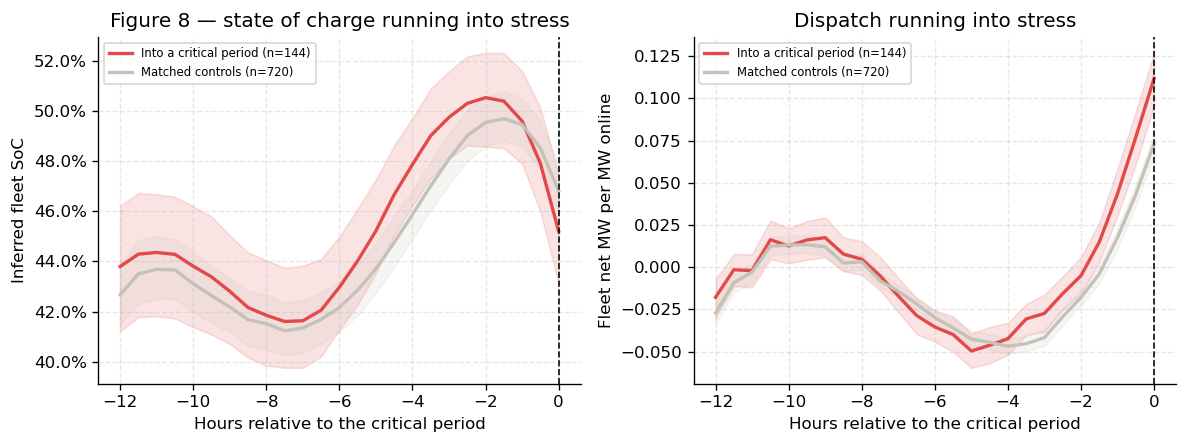

SoC at the critical period : 45.2% vs 46.8% in controls (-1.6%)
SoC 6 h earlier            : 43.0% vs 42.2%
Sensitivity (re-anchored)  : 43.8% vs 48.7% (-5.0%); schemes agree on sign (primary -1.6%)


In [15]:
crit_days = set(pd.DatetimeIndex(grid[CRITICAL]).date)
control_pool = {}
for ts in grid:
    if ts.date() in crit_days:
        continue
    control_pool.setdefault((ts.month, ts.hour, ts.minute), []).append(ts)

onsets = grid[CRITICAL & ~pd.Series(CRITICAL, index=grid).shift(1, fill_value=False).values]
rng = np.random.default_rng(7)


def matched_controls(t0, k=MAX_CONTROLS):
    pool = control_pool.get((t0.month, t0.hour, t0.minute), [])
    if not pool:
        return []
    take = min(k, len(pool))
    return list(rng.choice(np.array(pool, dtype=object), size=take, replace=False))


def trajectory(series, anchors, back=LOOKBACK_HH, fwd=0):
    '''Mean profile of ``series`` at half-hour offsets around each anchor.'''
    offsets = range(-back, fwd + 1)
    rows = []
    for a in anchors:
        rows.append([series.get(a + pd.Timedelta(minutes=30 * o), np.nan) for o in offsets])
    arr = np.array(rows, dtype=float)
    return pd.DataFrame(arr, columns=[o * 0.5 for o in offsets])


def boot_ci(frame, n=400):
    '''Percentile bootstrap CI of the column means, over events.'''
    if len(frame) < 3:
        return None, None
    with warnings.catch_warnings():
        # A resample can draw only all-NaN rows for an offset; nanmean warns
        # and returns NaN, which is the answer we want anyway.
        warnings.simplefilter("ignore", RuntimeWarning)
        means = np.array([np.nanmean(frame.sample(len(frame), replace=True).values, axis=0)
                          for _ in range(n)])
        return np.nanpercentile(means, 2.5, axis=0), np.nanpercentile(means, 97.5, axis=0)


if len(onsets) == 0 or not len(USABLE_SOC):
    skip("no critical onset or no SoC-usable site — run-up analysis unavailable")
else:
    ctrl_anchors = [c for t0 in onsets for c in matched_controls(t0)]
    ev_soc = trajectory(fleet_soc, onsets)
    ct_soc = trajectory(fleet_soc, ctrl_anchors)
    ev_net = trajectory(norm_net, onsets)
    ct_net = trajectory(norm_net, ctrl_anchors)
    print(f"Critical onsets: {len(onsets)} | matched control anchors: {len(ctrl_anchors)}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
    for ax, ev, ct, label, fmt in (
        (axes[0], ev_soc, ct_soc, "Inferred fleet SoC", mticker.PercentFormatter(1.0)),
        (axes[1], ev_net, ct_net, "Fleet net MW per MW online", None),
    ):
        x = ev.columns.astype(float)
        for frame, colour, name in ((ev, C["cost"], f"Into a critical period (n={len(ev)})"),
                                    (ct, C["ghost"], f"Matched controls (n={len(ct)})")):
            if not len(frame):
                continue
            mean = np.nanmean(frame.values, axis=0)
            ax.plot(x, mean, color=colour, lw=2, label=name)
            lo, hi = boot_ci(frame)
            if lo is not None:
                ax.fill_between(x, lo, hi, color=colour, alpha=0.15)
        ax.axvline(0, color=C["ink"], lw=1, ls="--")
        ax.set_xlabel("Hours relative to the critical period")
        ax.set_ylabel(label)
        if fmt:
            ax.yaxis.set_major_formatter(fmt)
        ax.legend(fontsize=7)
    axes[0].set_title("Figure 8 — state of charge running into stress")
    axes[1].set_title("Dispatch running into stress")
    plt.tight_layout()
    plt.show()

    at_zero_ev, at_zero_ct = np.nanmean(ev_soc[0.0]), np.nanmean(ct_soc[0.0])
    print(f"SoC at the critical period : {at_zero_ev:.1%} vs {at_zero_ct:.1%} in controls "
          f"({at_zero_ev - at_zero_ct:+.1%})")
    print(f"SoC 6 h earlier            : {np.nanmean(ev_soc[-6.0]):.1%} vs "
          f"{np.nanmean(ct_soc[-6.0]):.1%}")

    # Robustness: the same comparison under the daily-re-anchored SoC scheme.
    ev_a = trajectory(fleet_soc_anchor, onsets)
    ct_a = trajectory(fleet_soc_anchor, ctrl_anchors)
    d_primary = np.nanmean(ev_soc[0.0]) - np.nanmean(ct_soc[0.0])
    d_anchor = np.nanmean(ev_a[0.0]) - np.nanmean(ct_a[0.0])
    agree = "agree" if np.sign(d_primary) == np.sign(d_anchor) else "DISAGREE"
    print(f"Sensitivity (re-anchored)  : {np.nanmean(ev_a[0.0]):.1%} vs "
          f"{np.nanmean(ct_a[0.0]):.1%} ({d_anchor:+.1%}); schemes {agree} on sign "
          f"(primary {d_primary:+.1%})")

Triggered events: 129 | median lead from trigger to the period: 11.9 h


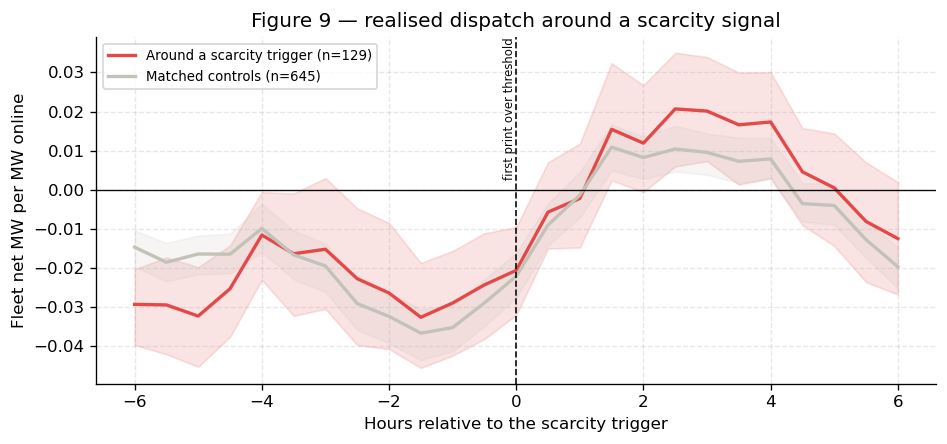

Mean net response in the 4 h after the trigger: +0.008 MW/MW vs +0.002 in controls


In [16]:
trig = prints[(prints["drm_mw"] < DRM_CRITICAL_MW) | (prints["lolp"] > 0)]
trigger_time = trig.groupby("time")["publish_time"].min()

events = [t for t in onsets if t in trigger_time.index]
if not events:
    skip("no critical period carried an advance trigger print — event study unavailable")
else:
    ev_rows, ct_rows = [], []
    for t0 in events:
        t_trig = trigger_time[t0].floor("30min")
        lead = t0 - t_trig
        ev_rows.append(t_trig)
        for c0 in matched_controls(t0):
            ct_rows.append(c0 - lead)

    ev_prof = trajectory(norm_net, ev_rows, back=EVENT_HH, fwd=EVENT_HH)
    ct_prof = trajectory(norm_net, ct_rows, back=EVENT_HH, fwd=EVENT_HH)
    leads = pd.Series([(t0 - trigger_time[t0]).total_seconds() / 3600 for t0 in events])
    print(f"Triggered events: {len(events)} | median lead from trigger to the period: "
          f"{leads.median():.1f} h")

    fig, ax = plt.subplots(figsize=(8, 3.8))
    x = ev_prof.columns.astype(float)
    for frame, colour, name in ((ev_prof, C["cost"], f"Around a scarcity trigger (n={len(ev_prof)})"),
                                (ct_prof, C["ghost"], f"Matched controls (n={len(ct_prof)})")):
        if not len(frame):
            continue
        ax.plot(x, np.nanmean(frame.values, axis=0), color=colour, lw=2, label=name)
        lo, hi = boot_ci(frame)
        if lo is not None:
            ax.fill_between(x, lo, hi, color=colour, alpha=0.15)
    ax.axvline(0, color=C["ink"], lw=1, ls="--")
    ax.annotate("first print over threshold", (0, ax.get_ylim()[1]), fontsize=7,
                rotation=90, va="top", ha="right", color=C["ink"])
    ax.axhline(0, color=C["ink"], lw=0.8)
    ax.set_xlabel("Hours relative to the scarcity trigger")
    ax.set_ylabel("Fleet net MW per MW online")
    ax.legend(fontsize=8)
    ax.set_title("Figure 9 — realised dispatch around a scarcity signal")
    plt.tight_layout()
    plt.show()

    post = ev_prof[[c for c in ev_prof.columns if 0 <= c <= 4]]
    post_c = ct_prof[[c for c in ct_prof.columns if 0 <= c <= 4]]
    print(f"Mean net response in the 4 h after the trigger: "
          f"{np.nanmean(post.values):+.3f} MW/MW vs {np.nanmean(post_c.values):+.3f} in controls")

## 7. RQ4 — Consumer value: does fleet discharge suppress cashout spikes?

Batteries discharge *because* prices spike, so a naive comparison would simply rediscover that
high prices and high discharge coincide. The design here holds system stress constant: within
each de-rated-margin band, periods are split into fleet-discharge quartiles and spike
frequencies compared across them. Two periods in the same band faced comparable physical
tightness, so the residual difference is the fleet's contribution — **associationally**, and
with the reverse-causality caveat still live.

GB has run a single cashout price since 2015, so the system buy price alone describes the
imbalance market.

RQ4 — cashout spikes by margin band and fleet-discharge quartile
                       n  mean_sbp   p95_sbp  pct_over_500  pct_over_1000
band   quartile                                                          
<1,000 —             2.0   180.000   180.000         0.000          0.000
1–2k   Q1            4.0   609.500  1684.500         0.250          0.250
       Q2            4.0   190.405   255.650         0.000          0.000
       Q3            3.0  1210.503  2672.901         0.667          0.333
       Q4            4.0  1750.869  2900.000         1.000          0.500
2–4k   Q1           49.0   308.508  1410.000         0.082          0.061
       Q2           48.0   270.387   528.250         0.062          0.042
       Q3           48.0   220.688   568.550         0.062          0.021
       Q4           48.0   161.247   318.582         0.042          0.000
4–7k   Q1          343.0   119.827   198.975         0.009          0.000
       Q2          343.0   114.916   188.660   

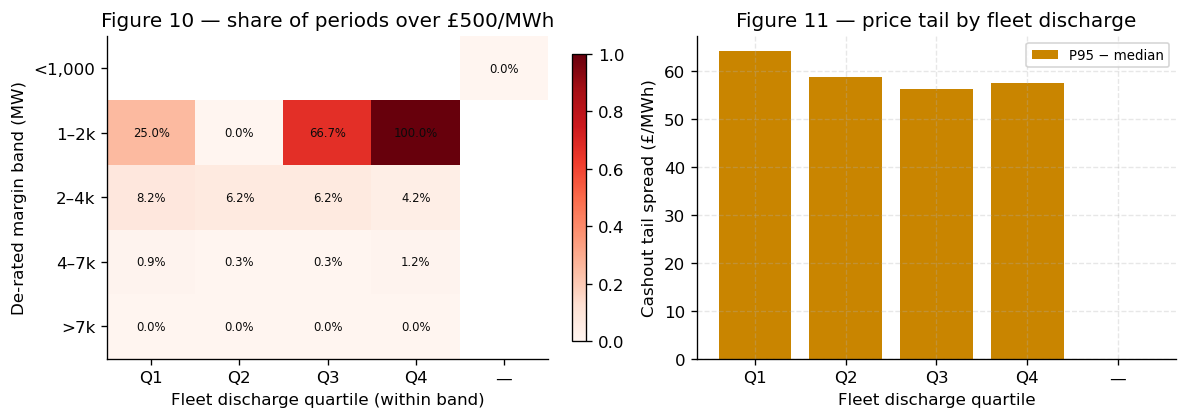

In [17]:
price = sbp["system_buy_price"].reindex(grid) if "system_buy_price" in sbp.columns else pd.Series(dtype=float)
rq4 = pd.DataFrame({"drm": drm, "sbp": price, "norm": norm_net, "net": fleet_net}).dropna()

if rq4.empty:
    skip("no period has DRM, cashout price and fleet data together")
    vdi = np.nan
else:
    rq4["band"] = pd.cut(rq4["drm"], DRM_BANDS, labels=DRM_BAND_LABELS, right=False)
    rq4["quartile"] = (rq4.groupby("band", observed=True)["norm"]
                          .transform(lambda s: pd.qcut(s, 4, labels=["Q1", "Q2", "Q3", "Q4"],
                                                       duplicates="drop")
                                     if s.nunique() > 4 else pd.Series("—", index=s.index)))

    def spike_stats(g):
        return pd.Series({
            "n": len(g),
            "mean_sbp": g["sbp"].mean(),
            "p95_sbp": g["sbp"].quantile(0.95),
            f"pct_over_{int(SPIKE_LEVELS[0])}": (g["sbp"] > SPIKE_LEVELS[0]).mean(),
            f"pct_over_{int(SPIKE_LEVELS[1])}": (g["sbp"] > SPIKE_LEVELS[1]).mean(),
        })

    table = rq4.groupby(["band", "quartile"], observed=True).apply(spike_stats,
                                                                  include_groups=False)
    print("RQ4 — cashout spikes by margin band and fleet-discharge quartile")
    print(table.round(3).to_string())

    # Volatility Dampening Index: tail compression at equal stress.
    rq4["drm_decile"] = pd.qcut(rq4["drm"], 10, labels=False, duplicates="drop")
    parts, weights = [], []
    for _, g in rq4.groupby("drm_decile", observed=True):
        if g["norm"].nunique() < 3 or len(g) < 30:
            continue
        terciles = pd.qcut(g["norm"], 3, labels=["low", "mid", "high"], duplicates="drop")
        if terciles.nunique() < 3:
            continue
        lo = g.loc[terciles == "low", "sbp"]
        hi = g.loc[terciles == "high", "sbp"]
        parts.append((lo.quantile(0.95) - lo.quantile(0.5))
                     - (hi.quantile(0.95) - hi.quantile(0.5)))
        weights.append(len(g))
    vdi = float(np.average(parts, weights=weights)) if parts else np.nan
    print(f"\nVolatility Dampening Index: "
          f"{'—' if np.isnan(vdi) else f'£{vdi:,.0f}/MWh'} "
          f"(positive ⇒ tails compressed when the fleet discharges, at equal stress; "
          f"{len(parts)} margin deciles used)")

    heat = table[f"pct_over_{int(SPIKE_LEVELS[0])}"].unstack("quartile")
    if heat.notna().any().any() and heat.shape[1] > 1:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
        ax = axes[0]
        im = ax.imshow(heat.values, cmap="Reds", aspect="auto")
        ax.set_xticks(range(heat.shape[1])); ax.set_xticklabels(heat.columns)
        ax.set_yticks(range(heat.shape[0])); ax.set_yticklabels(heat.index)
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                v = heat.values[i, j]
                if pd.notna(v):
                    ax.annotate(f"{v:.1%}", (j, i), ha="center", va="center", fontsize=7,
                                color=C["ink"])
        ax.set_xlabel("Fleet discharge quartile (within band)")
        ax.set_ylabel("De-rated margin band (MW)")
        ax.set_title(f"Figure 10 — share of periods over £{SPIKE_LEVELS[0]:,.0f}/MWh")
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=0.03)

        ax = axes[1]
        by_q = rq4.groupby("quartile", observed=True)["sbp"].agg(
            **{"median": "median", "p95": lambda s: s.quantile(0.95)})
        idx = range(len(by_q))
        ax.bar(idx, by_q["p95"] - by_q["median"], color=C["mid"], label="P95 − median")
        ax.set_xticks(list(idx)); ax.set_xticklabels(by_q.index)
        ax.set_xlabel("Fleet discharge quartile")
        ax.set_ylabel("Cashout tail spread (£/MWh)")
        ax.set_title("Figure 11 — price tail by fleet discharge")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        skip("not enough within-band variation in fleet discharge to form quartiles")

## 8. Limitations

1. **Physical Notifications are final-only.** Elexon does not publish PN revision history, so
   Section 6 measures realised dispatch around a scarcity signal. It cannot show an operator
   changing plan, and must not be read as proof of reaction.
2. **State of charge is inferred, never observed.** It integrates PN power against approximate
   nameplate energy, and is computed only for sites whose energy capacity is actually
   published; ancillary throughput and any trading not reflected in PNs are invisible.
   The usability filter and the daily-re-anchor sensitivity bound the damage rather than
   remove it.
3. **The population is the BM-registered census, and its edge is measured.** Every
   BM-registered GB battery site identified in notebook 06 — 90 sites, 127 BM Units — not the
   23-site curated cross-section the live dashboard renders. Two limits remain and neither is
   closable from public data. *Aggregator-traded batteries are structurally invisible*: a unit
   trading behind a VLP or supplier portfolio has no per-BMU feed, and on recent auction
   results those portfolios take roughly half of all battery ancillary revenue, so a material
   share of the fleet cannot be seen at site level by any method here. *Energy capacity is
   published only through Capacity Market agreements*, which match a BM Unit for a minority of
   sites, so state-of-charge and cycle figures are computed over the known-MWh subset and say
   so; MW-normalised figures span the whole census.
4. **The trend in 4b is conditioned on relative tightness, not scarcity.** It measures
   response to each quarter's own tightest decile, which is what makes it comparable across
   seasons — but it is not evidence of scarcity reliability. The operator-grade series over
   the same window is non-monotonic (0.164 → 0.097 → 0.143 MW/MW across three winters), and
   the 2024/25 dip coincides with roughly 2.5x more qualifying scarcity periods, consistent
   with duration-limited assets running out of energy rather than declining willingness.
5. **Fleet composition drifts hard.** The tracked fleet roughly doubles across the window, so
   every fleet statistic is normalised per MW online; absolute-MW comparisons across years are
   not meaningful.
6. **RQ4 is associational.** Batteries discharge because prices spike. Matching within
   de-rated-margin bands holds physical stress roughly constant, but does not identify a causal
   effect, and the consumer-cost framing is illustrative only.
7. **Rare events are rare.** Loss-of-load probability is zero in the overwhelming majority of
   periods and Capacity Market Notices number in the single digits. Every statistic reports its
   n; the notice analysis is explicitly a set of case studies.
8. **MELS is declared capability, not proven output.** A unit can declare availability it
   would struggle to deliver; the availability factor measures what the operator could see.
9. **Residual load is transmission-metered.** Embedded generation nets off before it is
   observed, which is why the operator-grade signals (LoLP, DRM, CMN) carry the stress
   definitions here and the residual-load decile is kept only as the tier-1 comparator.

In [18]:
def _fmt(row, col, fmt="{:+.3f}"):
    return "—" if row is None or col not in row or pd.isna(row[col]) else fmt.format(row[col])


print("=" * 72)
print("  STRESS RESPONSE STUDY — HEADLINE NUMBERS")
print("=" * 72)
print(f"  Window                     : {WINDOW_START} → {WINDOW_END} ({len(DAYS)} days)")
print(f"  Classified half-hours      : {len(grid):,}  ({int(known.sum()):,} with LoLP/DRM)")
print(f"  Tracked fleet              : {online_mw.iloc[0]:,.0f} → {online_mw.iloc[-1]:,.0f} MW "
      f"({int(online_n.iloc[-1])} sites)")
print("-" * 72)
print(f"  RQ1  Fleet net, all periods: {_fmt(rq1.loc['All periods'], 'net_MW_per_MW')} MW/MW online")
for name in ("C_LOLP", "C_DRM (p1)", "C_DRM<1GW", "C_CMN"):
    row = rq1.loc[name]
    if row["n"] == 0:
        print(f"       {name:<22}: n=0 (no such period in window)")
        continue
    print(f"       {name:<22}: {_fmt(row, 'net_MW_per_MW')} MW/MW · "
          f"availability {_fmt(row, 'avail_factor', '{:.0%}')} · "
          f"SoC {_fmt(row, 'mean_SoC', '{:.0%}')} · n={int(row['n'])}")
print("-" * 72)
if not rq2.empty and rq2.iloc[0]["n"] > 0:
    t = rq2.iloc[0]
    print(f"  RQ2  DRM < 1 GW (n={int(t['n'])})    : fleet charging in "
          f"{t['charging_share']:.0%} of periods, mean net {t['mean_net_MW']:+,.0f} MW")
else:
    print("  RQ2  DRM < 1 GW            : n=0 in window")
print("-" * 72)
if len(warning_h.dropna()):
    seen = warning_h.dropna()
    print(f"  RQ3  Advance visibility    : {len(seen)}/{len(warning_h)} critical periods "
          f"({len(seen) / max(len(warning_h), 1):.0%}), median {seen.median():.0f} h of warning")
else:
    print("  RQ3  Advance visibility    : no critical period with prints")
if len(USABLE_SOC) and len(onsets):
    print(f"       SoC at onset vs control: {np.nanmean(ev_soc[0.0]):.0%} vs "
          f"{np.nanmean(ct_soc[0.0]):.0%}")
if not cmn_issued.empty:
    print(f"       CMNs issued / standing at delivery: {len(cmn_issued)} / {survived}")
print("-" * 72)
if not rq4.empty:
    over = rq4[f"sbp"].gt(SPIKE_LEVELS[0]).mean()
    print(f"  RQ4  Cashout > £{SPIKE_LEVELS[0]:,.0f}/MWh   : {over:.2%} of all periods")
    print(f"       Volatility Dampening  : "
          f"{'—' if np.isnan(vdi) else f'£{vdi:,.0f}/MWh tail compression'}")
else:
    print("  RQ4  Cashout analysis      : unavailable (missing price or fleet data)")
print("=" * 72)
print("  Fleet statistics are normalised per MW online; SoC is inferred from PNs.")
print("  See Section 8 for the limitations these numbers must be read with.")
print("=" * 72)

  STRESS RESPONSE STUDY — HEADLINE NUMBERS
  Window                     : 2023-10-01 → 2026-08-16 (1051 days)
  Classified half-hours      : 50,447  (50,447 with LoLP/DRM)
  Tracked fleet              : 1,771 → 6,085 MW (82 sites)
------------------------------------------------------------------------
  RQ1  Fleet net, all periods: +0.000 MW/MW online
       C_LOLP                : +0.120 MW/MW · availability 30% · SoC 37% · n=505
       C_DRM (p1)            : +0.107 MW/MW · availability 32% · SoC 40% · n=505
       C_DRM<1GW             : +0.118 MW/MW · availability 24% · SoC 53% · n=2
       C_CMN                 : +0.122 MW/MW · availability 30% · SoC 47% · n=3
------------------------------------------------------------------------
  RQ2  DRM < 1 GW (n=2)    : fleet charging in 0% of periods, mean net +392 MW
------------------------------------------------------------------------
  RQ3  Advance visibility    : 654/685 critical periods (95%), median 12 h of warning
       SoC at 